# **데이터 연결**

In [1]:
import warnings
warnings.filterwarnings('ignore') # warning 무시


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
from scipy import stats

pd.set_option('display.max_columns', None)

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
# ============================================================
# 한글 폰트 설치 및 적용
# ============================================================

!apt-get -qq install -y fonts-nanum > /dev/null
!pip -q install scipy pandas matplotlib

import matplotlib.font_manager as fm
for f in fm.findSystemFonts():
    if 'Nanum' in f:
        fm.fontManager.addfont(f)
print("폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.")


plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

C = ['#2563eb', '#dc2626', '#16a34a', '#d97706',
     '#7c3aed', '#0891b2', '#db2777', '#65a30d']



폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.


In [4]:
#파일 불러오기
df = pd.read_csv('FDA_adverse_events_final.csv')
df

,report_id,receive_date,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,is_disabling,reactions,primary_reaction,reaction_outcomes,patient_recovered,num_reactions,suspect_drug,brand_name,drug_route,drug_indication,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,WHO_ATC
0,10019350,2015-02-24,2015Q1,Yes,Death; Hospitalization,True,True,False,False,Overdose; Multi-organ failure; Hepatic failure,Overdose,Unknown,False,3,"ACETAMINOPHEN, GUAIFENESIN, AND PHENYLEPHRINE ...",TYLENOL COLD PLUS HEAD CONGESTION SEVERE; TYLE...,65.0,Unknown,Kenvue Brands Llc,Expectorant [EPC],3,2-3 Drugs,Unknown,Unknown,Male,Unknown,CA,N
1,10019352,2015-02-24,2015Q1,Yes,Hospitalization,False,True,False,False,Overdose; Toxicity to various agents,Overdose,Unknown,False,2,ACETAMINOPHEN; ACETAMINOPHEN 500MG; ACETAMINOP...,AMAZON BASIC CARE ACETAMINOPHEN; PAIN RELIEF; ...,65.0,Unknown,"Amazon.Com Services Llc; Meijer, Inc.; Jhk Inc...",Nonsteroidal Anti-inflammatory Drug [EPC],2,2-3 Drugs,Unknown,Unknown,Unknown,Unknown,GB,N
2,10064442,2015-02-23,2015Q1,Yes,Hospitalization,False,True,False,False,Intentional overdose; Suicide attempt,Intentional overdose,Unknown,False,2,PARACETAMOL,Unknown,65.0,Unknown,Unknown,Unknown,3,2-3 Drugs,Unknown,Unknown,Unknown,Unknown,AU,N
3,10083990,2015-02-24,2015Q1,Yes,Death; Hospitalization,True,True,False,False,Overdose; Intestinal ischaemia; Renal failure;...,Overdose,Unknown,False,6,ACETAMINOPHEN,TYLENOL EXTRA STRENGTH; TYLENOL EXTRA STRENGTH...,65.0,Unknown,"Kenvue Brands Llc; Lil' Drug Store Products, I...",Unknown,2,2-3 Drugs,36.0,Adult(19-40),Female,Unknown,CA,N
4,10052600,2015-01-02,2015Q1,No,Unknown,False,False,False,False,Dizziness; Drug ineffective; Adverse event,Dizziness,Unknown,False,3,ACETAMINOPHEN AND CHLORPHENIRAMINE MALEATE,CORICIDIN HBP COLD AND FLU,48.0,Unknown,Bayer Healthcare Llc.,Unknown,2,2-3 Drugs,Unknown,Unknown,Female,Unknown,US,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18268,15425170,2024-09-13,2024Q3,Yes,Death; Hospitalization,True,True,False,False,Cholestasis; Cell death,Cholestasis,Unknown,False,2,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,48.0,Anaemia,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,24,Polypharmacy(6+),84.0,Elderly(81+),Male,89.0,FR,B
18269,15764217,2024-09-26,2024Q3,Yes,Unknown,False,False,False,False,Seizure; Fall,Seizure,Unknown,False,2,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,65.0,Product Used For Unknown Indication,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,8,Polypharmacy(6+),84.0,Elderly(81+),Male,Unknown,DE,B
18270,16437469,2025-07-21,2025Q3,Yes,Hospitalization,False,True,False,False,Respiratory distress; Hyperbilirubinaemia; Ana...,Respiratory distress,Unknown,False,8,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,64.0,Product Used For Unknown Indication,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,10,Polypharmacy(6+),Unknown,Unknown,Male,0.87,EU,B
18271,16671972,2025-08-13,2025Q3,Yes,Unknown,False,False,False,False,Tibia fracture; Foot fracture; Fibula fracture,Tibia fracture,Unknown,False,3,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,65.0,Product Used For Unknown Indication,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,5,4-5 Drugs,66.0,Senior(66-80),Male,Unknown,EU,B


In [5]:
# 생략되는 부분 없이 다 볼 수 있게 설정
pd.set_option('display.max_columns', None)

# (선택 사항) 컬럼 안의 내용이 길어서 잘릴 경우, 아래 설정도 추가
# pd.set_option('display.max_colwidth', None)

# 다시 확인
df

,report_id,receive_date,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,is_disabling,reactions,primary_reaction,reaction_outcomes,patient_recovered,num_reactions,suspect_drug,brand_name,drug_route,drug_indication,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,WHO_ATC
0,10019350,2015-02-24,2015Q1,Yes,Death; Hospitalization,True,True,False,False,Overdose; Multi-organ failure; Hepatic failure,Overdose,Unknown,False,3,"ACETAMINOPHEN, GUAIFENESIN, AND PHENYLEPHRINE ...",TYLENOL COLD PLUS HEAD CONGESTION SEVERE; TYLE...,65.0,Unknown,Kenvue Brands Llc,Expectorant [EPC],3,2-3 Drugs,Unknown,Unknown,Male,Unknown,CA,N
1,10019352,2015-02-24,2015Q1,Yes,Hospitalization,False,True,False,False,Overdose; Toxicity to various agents,Overdose,Unknown,False,2,ACETAMINOPHEN; ACETAMINOPHEN 500MG; ACETAMINOP...,AMAZON BASIC CARE ACETAMINOPHEN; PAIN RELIEF; ...,65.0,Unknown,"Amazon.Com Services Llc; Meijer, Inc.; Jhk Inc...",Nonsteroidal Anti-inflammatory Drug [EPC],2,2-3 Drugs,Unknown,Unknown,Unknown,Unknown,GB,N
2,10064442,2015-02-23,2015Q1,Yes,Hospitalization,False,True,False,False,Intentional overdose; Suicide attempt,Intentional overdose,Unknown,False,2,PARACETAMOL,Unknown,65.0,Unknown,Unknown,Unknown,3,2-3 Drugs,Unknown,Unknown,Unknown,Unknown,AU,N
3,10083990,2015-02-24,2015Q1,Yes,Death; Hospitalization,True,True,False,False,Overdose; Intestinal ischaemia; Renal failure;...,Overdose,Unknown,False,6,ACETAMINOPHEN,TYLENOL EXTRA STRENGTH; TYLENOL EXTRA STRENGTH...,65.0,Unknown,"Kenvue Brands Llc; Lil' Drug Store Products, I...",Unknown,2,2-3 Drugs,36.0,Adult(19-40),Female,Unknown,CA,N
4,10052600,2015-01-02,2015Q1,No,Unknown,False,False,False,False,Dizziness; Drug ineffective; Adverse event,Dizziness,Unknown,False,3,ACETAMINOPHEN AND CHLORPHENIRAMINE MALEATE,CORICIDIN HBP COLD AND FLU,48.0,Unknown,Bayer Healthcare Llc.,Unknown,2,2-3 Drugs,Unknown,Unknown,Female,Unknown,US,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18268,15425170,2024-09-13,2024Q3,Yes,Death; Hospitalization,True,True,False,False,Cholestasis; Cell death,Cholestasis,Unknown,False,2,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,48.0,Anaemia,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,24,Polypharmacy(6+),84.0,Elderly(81+),Male,89.0,FR,B
18269,15764217,2024-09-26,2024Q3,Yes,Unknown,False,False,False,False,Seizure; Fall,Seizure,Unknown,False,2,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,65.0,Product Used For Unknown Indication,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,8,Polypharmacy(6+),84.0,Elderly(81+),Male,Unknown,DE,B
18270,16437469,2025-07-21,2025Q3,Yes,Hospitalization,False,True,False,False,Respiratory distress; Hyperbilirubinaemia; Ana...,Respiratory distress,Unknown,False,8,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,64.0,Product Used For Unknown Indication,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,10,Polypharmacy(6+),Unknown,Unknown,Male,0.87,EU,B
18271,16671972,2025-08-13,2025Q3,Yes,Unknown,False,False,False,False,Tibia fracture; Foot fracture; Fibula fracture,Tibia fracture,Unknown,False,3,FOLIC ACID,VENTRIXYL; FOLIC ACID; QUIOFIC; VENEXA; VITRAMYN,65.0,Product Used For Unknown Indication,"Puretek Corporation; Leading Pharma, Llc; Amne...",Vitamin C [EPC]; Vitamin D [EPC]; Vitamin B12 ...,5,4-5 Drugs,66.0,Senior(66-80),Male,Unknown,EU,B


# **데이터 시각화&통계**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18273 entries, 0 to 18272
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   report_id            18273 non-null  int64 
 1   receive_date         18273 non-null  object
 2   quarter              18273 non-null  object
 3   serious              18273 non-null  object
 4   serious_flags        18273 non-null  object
 5   is_fatal             18273 non-null  bool  
 6   is_hospitalized      18273 non-null  bool  
 7   is_life_threat       18273 non-null  bool  
 8   is_disabling         18273 non-null  bool  
 9   reactions            18273 non-null  object
 10  primary_reaction     18273 non-null  object
 11  reaction_outcomes    18273 non-null  object
 12  patient_recovered    18273 non-null  bool  
 13  num_reactions        18273 non-null  int64 
 14  suspect_drug         18273 non-null  object
 15  brand_name           18273 non-null  object
 16  drug

In [7]:
df.shape

(18273, 28)

# **WHO_ATC_N군**

In [8]:
df['WHO_ATC'].value_counts()

,count
WHO_ATC,
A,9622
N,4324
M,1975
R,1562
D,641
B,94
S,55


In [9]:
# ============================================================
# ATC 'N' 필터링
# ============================================================

print("\nWHO_ATC 분포:")
print(df['WHO_ATC'].value_counts(dropna=False))

n = df[df['WHO_ATC'] == 'N'].copy()
n['age'] = pd.to_numeric(n['patient_age_years'], errors='coerce')
n['weight'] = pd.to_numeric(n['patient_weight_kg'], errors='coerce')
print(f"\nATC 'N' 대상 건수: {len(n):,}")


WHO_ATC 분포:
WHO_ATC
A    9622
N    4324
M    1975
R    1562
D     641
B      94
S      55
Name: count, dtype: int64

ATC 'N' 대상 건수: 4,324


In [10]:

# %% [셀 5] 요약 통계 ----------------------------------------------
print("=== 핵심 요약 ===")
print(f"심각(serious) 비율 : {(n['serious']=='Yes').mean()*100:.1f}%")
print(f"치명(사망) 비율    : {n['is_fatal'].mean()*100:.1f}%  ({n['is_fatal'].sum():,}건)")
print(f"입원 비율          : {n['is_hospitalized'].mean()*100:.1f}%  ({n['is_hospitalized'].sum():,}건)")
print(f"생명위협 비율      : {n['is_life_threat'].mean()*100:.1f}%")
print(f"회복 비율          : {n['patient_recovered'].mean()*100:.1f}%")
print(f"다약제(6+) 비율    : {(n['drug_count_category']=='Polypharmacy(6+)').mean()*100:.1f}%")
print(f"미국(US) 비율      : {(n['country']=='US').mean()*100:.1f}%")
print(f"나이 중앙값        : {n['age'].median():.0f}세 (평균 {n['age'].mean():.1f})")



=== 핵심 요약 ===
심각(serious) 비율 : 88.1%
치명(사망) 비율    : 22.3%  (964건)
입원 비율          : 62.3%  (2,695건)
생명위협 비율      : 9.1%
회복 비율          : 29.9%
다약제(6+) 비율    : 37.5%
미국(US) 비율      : 56.7%
나이 중앙값        : 66세 (평균 59.0)


## **인체특성**

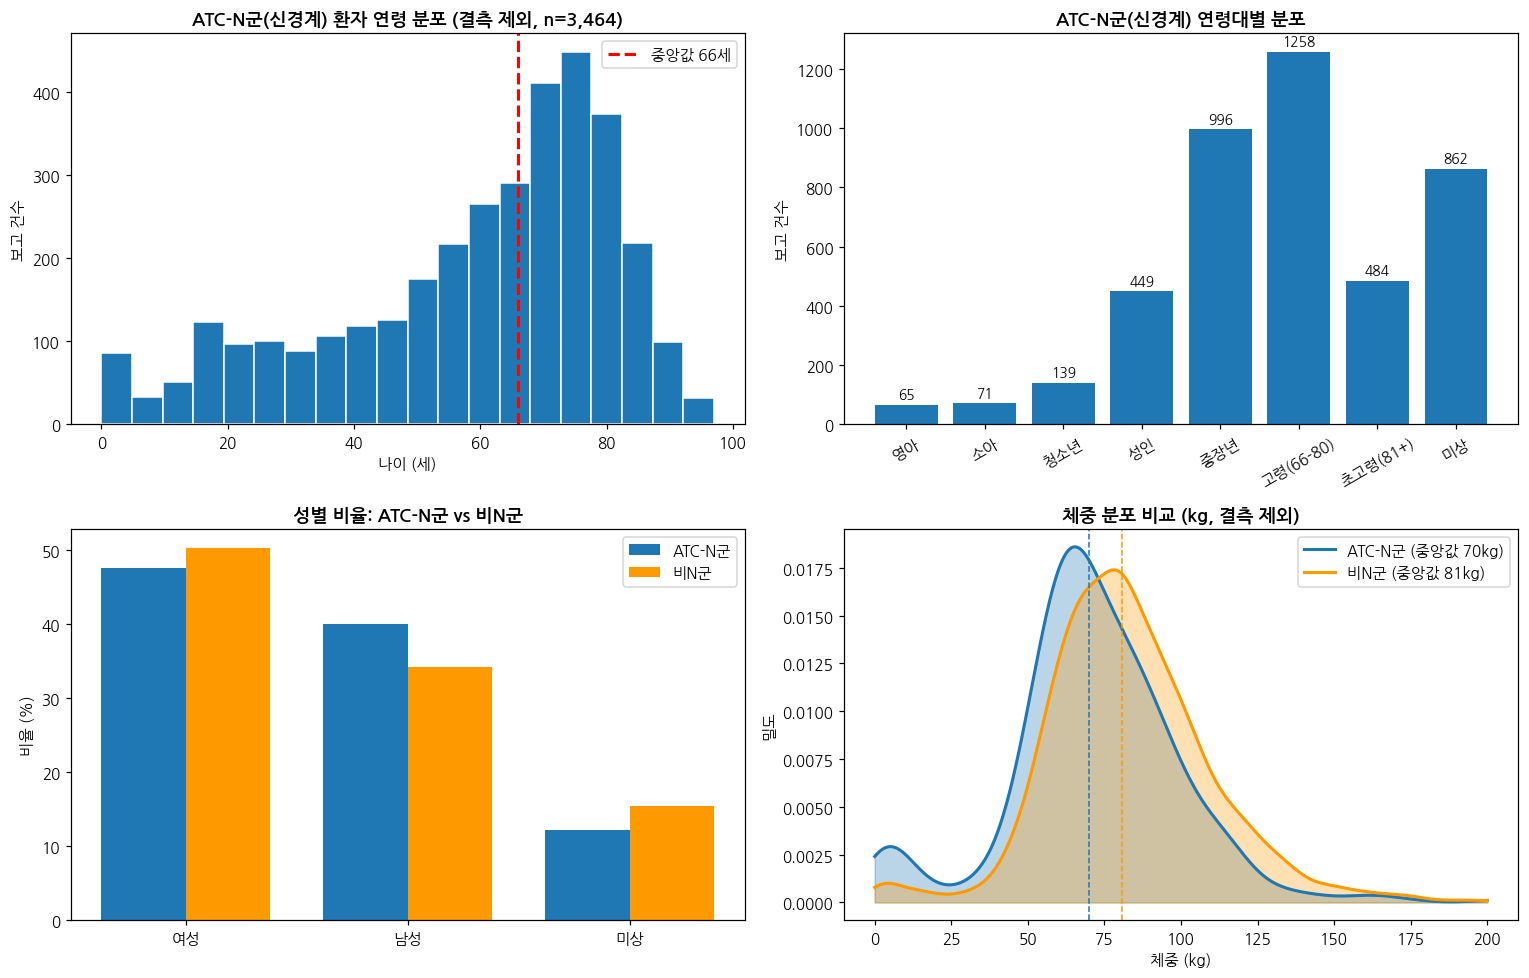

 ATC-N군 인구/체중 요약
· 연령: n=3,464, 중앙값 66세
· 최다 연령대: 고령(66-80) (1258건)
· 성별(N군): 여성 47.7%, 남성 40.1%, 미상 12.3%
· 성별(비N군): 여성 50.4%, 남성 34.2%, 미상 15.4%
· 체중 중앙값: N군 70.0kg (n=949) vs 비N군 80.7kg (n=4974)


In [11]:
# =====================================================================
#  ATC-N군 인구·체중 대시보드 (첨부 M군 대시보드와 동일 레이아웃)
#   좌상: 연령 히스토그램 + 중앙값 선
#   우상: 연령대별 보고 건수 막대
#   좌하: 성별 비율 N군 vs 비N군
#   우하: 체중 분포 박스플롯 N군 vs 비N군
#
#  방법론: Chain-of-Thought(주석 추론) + Self-Refine(정제→검증)
#  심각도 외 지표는 모두 '건수' 기준.
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# --- (df 가 앞 셀에서 로드돼 있으면 아래 2줄 생략) ---
# FILE = "FDA_adverse_events_final_중복값제거_듀플제거___몸무게_결측_제거.csv"
# df = pd.read_csv(FILE)

# 한글 폰트 (Colab 최초 1회: 주석 실행 후 런타임 재시작)
# !sudo apt-get -qq install -y fonts-nanum > /dev/null
try: matplotlib.rc('font', family='NanumGothic')
except Exception: pass
matplotlib.rcParams['axes.unicode_minus'] = False


# ---------------------------------------------------------------------
#  파생변수 & 정제  (Self-Refine 1단계)
# ---------------------------------------------------------------------
# CoT: 'Unknown' 문자열이 섞인 age/weight 컬럼을 숫자로 변환(결측 제외용),
#      연령대는 영문 → 한글 라벨로 매핑, 성별/체중은 그룹 비교용으로 정제.
df['is_N'] = (df['WHO_ATC'] == 'N')
N = df[df['is_N']].copy()

age_num    = pd.to_numeric(N['patient_age_years'], errors='coerce').dropna()
weight_N   = pd.to_numeric(df.loc[df['is_N'],  'patient_weight_kg'], errors='coerce').dropna()
weight_NN  = pd.to_numeric(df.loc[~df['is_N'], 'patient_weight_kg'], errors='coerce').dropna()

# 연령대 영문 → 한글 라벨 매핑 (원본 대시보드와 동일 표기)
age_map = {'Infant(0-2)':'영아','Child(3-12)':'소아','Teen(13-18)':'청소년',
           'Adult(19-40)':'성인','Middle-Aged(41-65)':'중장년',
           'Senior(66-80)':'고령(66-80)','Elderly(81+)':'초고령(81+)','Unknown':'미상'}
age_order = ['영아','소아','청소년','성인','중장년','고령(66-80)','초고령(81+)','미상']
ag = N['age_group'].map(age_map).value_counts().reindex(age_order).fillna(0).astype(int)

# 성별 비율 (여성/남성/미상)
sex_map = {'Female':'여성','Male':'남성','Unknown':'미상'}
sex_order = ['여성','남성','미상']
sex_N  = (N['patient_sex'].map(sex_map).value_counts(normalize=True)*100
          ).reindex(sex_order).fillna(0)
sex_NN = (df[~df['is_N']]['patient_sex'].map(sex_map).value_counts(normalize=True)*100
          ).reindex(sex_order).fillna(0)


# ---------------------------------------------------------------------
#  4-패널 대시보드
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
BLUE, ORANGE = '#1f77b4', '#ff9900'

# --- (1) 좌상: 연령 히스토그램 + 중앙값 ---
# CoT: 결측 제외한 실제 나이 분포. 중앙값을 빨간 점선으로 표시.
ax = axes[0,0]
ax.hist(age_num, bins=20, color=BLUE, edgecolor='white')
med = age_num.median()
ax.axvline(med, color='red', ls='--', lw=2, label=f'중앙값 {med:.0f}세')
ax.set_title(f'ATC-N군(신경계) 환자 연령 분포 (결측 제외, n={len(age_num):,})', fontweight='bold')
ax.set_xlabel('나이 (세)'); ax.set_ylabel('보고 건수'); ax.legend()

# --- (2) 우상: 연령대별 건수 ---
# CoT: 어느 연령대에 보고가 몰리는지. 막대 위 건수 라벨.
ax = axes[0,1]
bars = ax.bar(ag.index, ag.values, color=BLUE)
for b,v in zip(bars, ag.values):
    ax.text(b.get_x()+b.get_width()/2, v+max(ag.values)*0.01, f'{v}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('ATC-N군(신경계) 연령대별 분포', fontweight='bold')
ax.set_ylabel('보고 건수'); ax.tick_params(axis='x', rotation=30)

# --- (3) 좌하: 성별 비율 N군 vs 비N군 ---
# CoT: 비율(%)로 두 그룹 성비 비교. grouped bar.
ax = axes[1,0]
x = np.arange(len(sex_order)); w = 0.38
ax.bar(x-w/2, sex_N.values,  w, color=BLUE,   label='ATC-N군')
ax.bar(x+w/2, sex_NN.values, w, color=ORANGE, label='비N군')
ax.set_xticks(x); ax.set_xticklabels(sex_order)
ax.set_title('성별 비율: ATC-N군 vs 비N군', fontweight='bold')
ax.set_ylabel('비율 (%)'); ax.legend()

# --- (4) 우하: 체중 겹친 밀도곡선(KDE) N군 vs 비N군 ---
# CoT: 두 그룹의 체중 분포 '모양'과 봉우리 위치를 직접 비교한다.
#   - Self-Refine: 생리학적 극단치(1kg 이하, 250kg 이상) 제거 후 KDE 추정.
#   - 반투명 채움 + 중앙값 점선으로 두 분포의 이동을 강조.
from scipy.stats import gaussian_kde
wN  = weight_N[(weight_N > 1) & (weight_N < 250)]
wNN = weight_NN[(weight_NN > 1) & (weight_NN < 250)]
xs  = np.linspace(0, 200, 400)
kN, kNN = gaussian_kde(wN)(xs), gaussian_kde(wNN)(xs)

ax = axes[1,1]
ax.plot(xs, kN,  color=BLUE,   lw=2, label=f'ATC-N군 (중앙값 {wN.median():.0f}kg)')
ax.fill_between(xs, kN,  color=BLUE,   alpha=0.30)
ax.plot(xs, kNN, color=ORANGE, lw=2, label=f'비N군 (중앙값 {wNN.median():.0f}kg)')
ax.fill_between(xs, kNN, color=ORANGE, alpha=0.30)
ax.axvline(wN.median(),  color=BLUE,   ls='--', lw=1)
ax.axvline(wNN.median(), color=ORANGE, ls='--', lw=1)
ax.set_title('체중 분포 비교 (kg, 결측 제외)', fontweight='bold')
ax.set_xlabel('체중 (kg)'); ax.set_ylabel('밀도'); ax.legend()

plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
#  요약 출력  (Self-Refine 검증)
# ---------------------------------------------------------------------
print("="*55)
print(" ATC-N군 인구/체중 요약")
print("="*55)
print(f"· 연령: n={len(age_num):,}, 중앙값 {med:.0f}세")
print(f"· 최다 연령대: {ag.idxmax()} ({ag.max()}건)")
print(f"· 성별(N군): " + ", ".join(f"{k} {v:.1f}%" for k,v in sex_N.items()))
print(f"· 성별(비N군): " + ", ".join(f"{k} {v:.1f}%" for k,v in sex_NN.items()))
print(f"· 체중 중앙값: N군 {weight_N.median():.1f}kg (n={len(weight_N)}) "
      f"vs 비N군 {weight_NN.median():.1f}kg (n={len(weight_NN)})")
print("="*55)

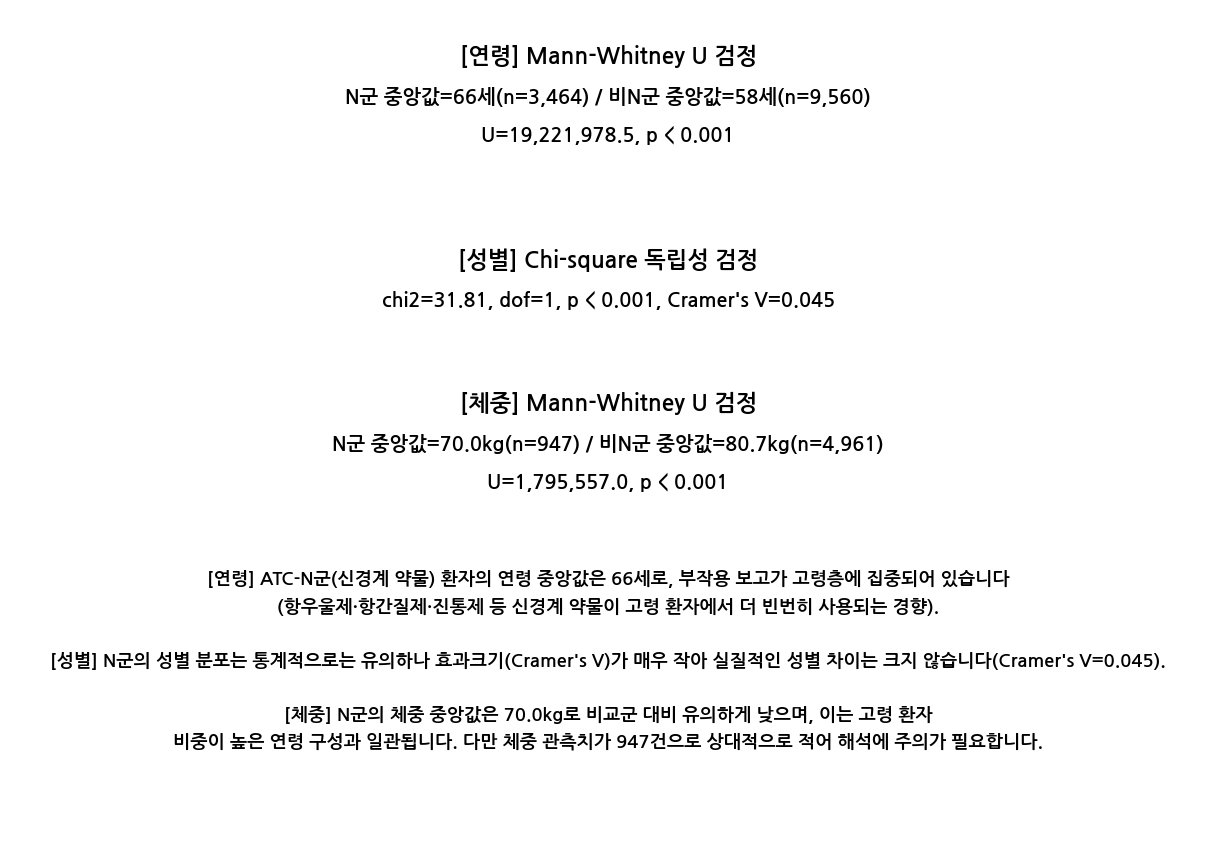

 ATC-N군 통계검정 요약
[연령] N 66세 vs 비N 58세 | U=19,221,978 p < 0.001
[성별] chi2=31.81 dof=1 p < 0.001 Cramer's V=0.045
[체중] N 70.0kg vs 비N 80.7kg | U=1,795,557 p < 0.001


In [12]:


# ---------------------------------------------------------------------
#  검정 수행  (Self-Refine: 정제 → 계산)
# ---------------------------------------------------------------------
df['is_N'] = (df['WHO_ATC'] == 'N')

def fmt_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

# CoT ① 연령: 연속형·비정규·대표본 → Mann-Whitney U (분포 위치 비교)
aN  = pd.to_numeric(df.loc[df['is_N'],  'patient_age_years'], errors='coerce').dropna()
aNN = pd.to_numeric(df.loc[~df['is_N'], 'patient_age_years'], errors='coerce').dropna()
u_a, p_a = stats.mannwhitneyu(aN, aNN, alternative='two-sided')

# CoT ② 성별: 범주형(남/여) → Chi-square 독립성 + 효과크기 Cramer's V
sub = df[df['patient_sex'].isin(['Male','Female'])]
ct  = pd.crosstab(sub['is_N'], sub['patient_sex'])
chi2, p_s, dof, _ = stats.chi2_contingency(ct)
n_s = ct.sum().sum()
cramer_v = np.sqrt(chi2 / (n_s * (min(ct.shape) - 1)))

# CoT ③ 체중: 연속형·비정규 → Mann-Whitney U. 극단치(1kg↓,250kg↑) 제거.
wN  = pd.to_numeric(df.loc[df['is_N'],  'patient_weight_kg'], errors='coerce').dropna()
wNN = pd.to_numeric(df.loc[~df['is_N'], 'patient_weight_kg'], errors='coerce').dropna()
wN  = wN[(wN > 1) & (wN < 250)]; wNN = wNN[(wNN > 1) & (wNN < 250)]
u_w, p_w = stats.mannwhitneyu(wN, wNN, alternative='two-sided')


# ---------------------------------------------------------------------
#  요약 카드 렌더링
# ---------------------------------------------------------------------
# CoT: 표가 아니라 '읽기 쉬운 카드'가 목적 → 축 없는 캔버스에 텍스트 배치.
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=15,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y - 0.05 - i*0.045, ln, ha='center', va='top',
                fontsize=13, fontweight='bold', transform=ax.transAxes)

# [연령]
block(0.96, "[연령] Mann-Whitney U 검정", [
    f"N군 중앙값={aN.median():.0f}세(n={len(aN):,}) / 비N군 중앙값={aNN.median():.0f}세(n={len(aNN):,})",
    f"U={u_a:,.1f}, {fmt_p(p_a)}"])

# [성별]
block(0.72, "[성별] Chi-square 독립성 검정", [
    f"chi2={chi2:.2f}, dof={dof}, {fmt_p(p_s)}, Cramer's V={cramer_v:.3f}"])

# [체중]
block(0.55, "[체중] Mann-Whitney U 검정", [
    f"N군 중앙값={wN.median():.1f}kg(n={len(wN):,}) / 비N군 중앙값={wNN.median():.1f}kg(n={len(wNN):,})",
    f"U={u_w:,.1f}, {fmt_p(p_w)}"])

# --- 하단 자연어 해석 ---
# CoT: 각 검정 결과를 N군 자체 인사이트로 서술. 유의성 + 효과크기 + 주의점.
sex_sig = ("통계적으로는 유의하나 효과크기(Cramer's V)가 매우 작아 "
           "실질적인 성별 차이는 크지 않습니다") if cramer_v < 0.1 \
          else "통계적으로 유의한 성별 차이가 있습니다"
interp = (
    "[연령] ATC-N군(신경계 약물) 환자의 연령 중앙값은 "
    f"{aN.median():.0f}세로, 부작용 보고가 고령층에 집중되어 있습니다\n"
    "(항우울제·항간질제·진통제 등 신경계 약물이 고령 환자에서 더 빈번히 사용되는 경향).\n\n"
    f"[성별] N군의 성별 분포는 {sex_sig}"
    f"(Cramer's V={cramer_v:.3f}).\n\n"
    f"[체중] N군의 체중 중앙값은 {wN.median():.1f}kg로 비교군 대비 유의하게 낮으며, "
    "이는 고령 환자\n비중이 높은 연령 구성과 일관됩니다. 다만 체중 관측치가 "
    f"{len(wN):,}건으로 상대적으로 적어 해석에 주의가 필요합니다."
)
ax.text(0.5, 0.34, interp, ha='center', va='top', fontsize=12,
        fontweight='bold', linespacing=1.7, transform=ax.transAxes)

plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
#  콘솔 검증 출력  (Self-Refine 최종 확인)
# ---------------------------------------------------------------------
print("="*58)
print(" ATC-N군 통계검정 요약")
print("="*58)
print(f"[연령] N {aN.median():.0f}세 vs 비N {aNN.median():.0f}세 | U={u_a:,.0f} {fmt_p(p_a)}")
print(f"[성별] chi2={chi2:.2f} dof={dof} {fmt_p(p_s)} Cramer's V={cramer_v:.3f}")
print(f"[체중] N {wN.median():.1f}kg vs 비N {wNN.median():.1f}kg | U={u_w:,.0f} {fmt_p(p_w)}")
print("="*58)

## **약물**

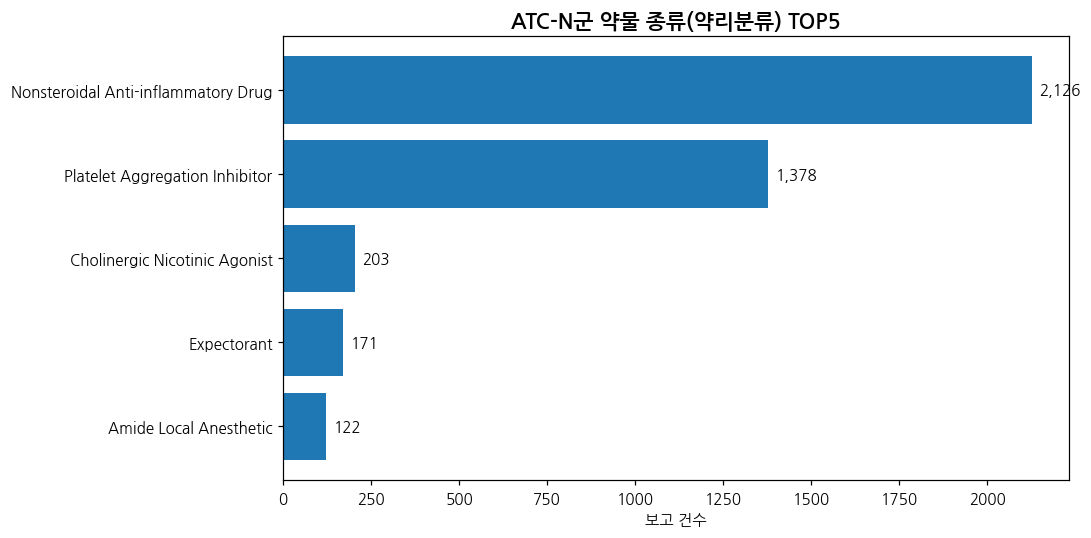

[약리분류 적합도] chi2=4130.1, p < 0.001 → 특정 계열 편중


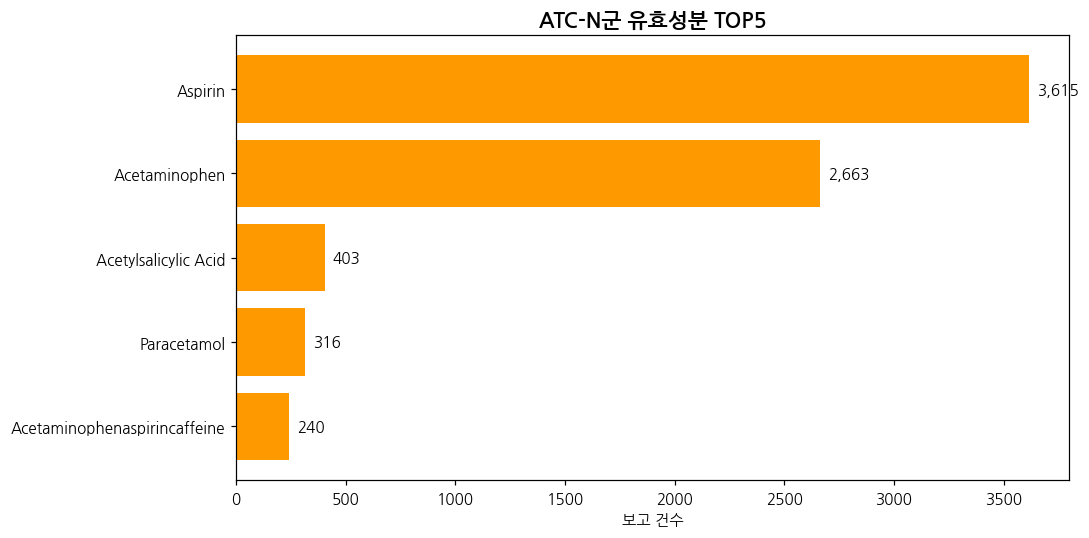

[유효성분 적합도] chi2=6912.3, p < 0.001 → 소수 성분 편중


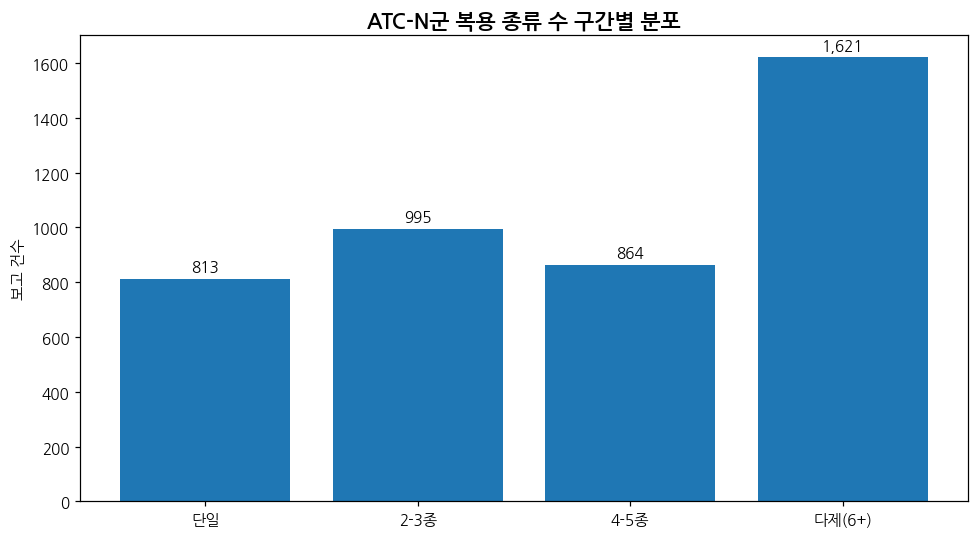

[복용구간 적합도] chi2=389.2, p < 0.001 → 최다 구간: 다제(6+) (1,621건)


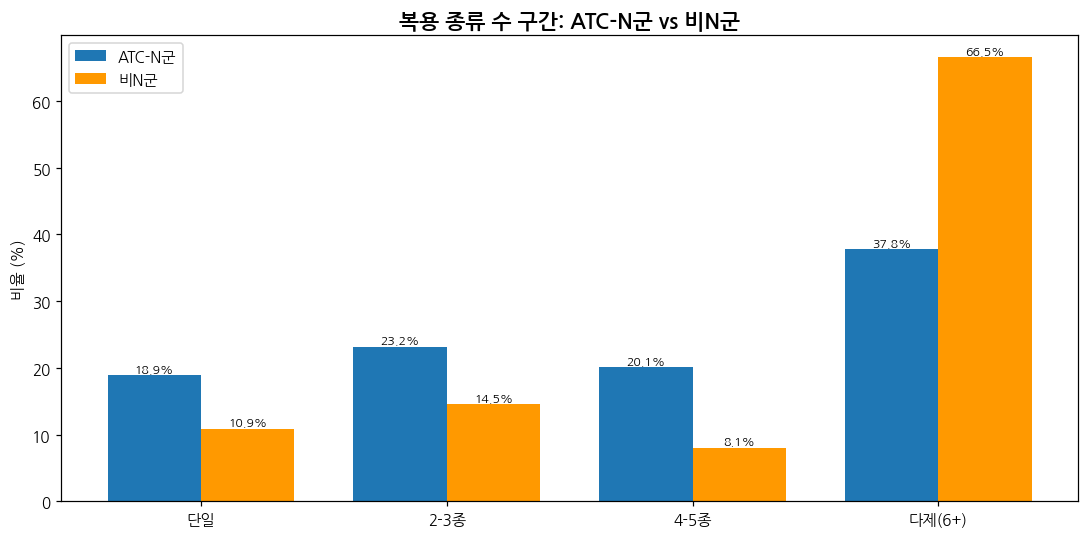

[복용구간 독립성] chi2=1204.3, dof=3, p < 0.001, Cramer's V=0.258


In [13]:
# =====================================================================
#  ATC-N군 약물 분석 4종 + 통계검정 카드
#   (1) N군 약물 종류(약리분류) TOP5   : 카이제곱 적합도
#   (2) N군 유효성분 TOP5              : 카이제곱 적합도
#   (3) N군 복용 종류 수 구간          : 카이제곱 적합도
#   (4) N군 vs 비N군 복용 종류 수      : 카이제곱 독립성 + Cramer's V
#
#  방법론: CoT(검정 선택 근거 주석) + Self-Refine(정제→계산→검증)
#  심각도 외 지표는 모두 '건수' 기준.
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
from scipy import stats

# --- (df 가 앞 셀에서 로드돼 있으면 아래 2줄 생략) ---
# FILE = "FDA_adverse_events_final_중복값제거_듀플제거___몸무게_결측_제거.csv"
# df = pd.read_csv(FILE)

# 한글 폰트 (Colab 최초 1회: 주석 실행 후 런타임 재시작)
# !sudo apt-get -qq install -y fonts-nanum > /dev/null
try: matplotlib.rc('font', family='NanumGothic')
except Exception: pass
matplotlib.rcParams['axes.unicode_minus'] = False

df['is_N'] = (df['WHO_ATC'] == 'N')
N = df[df['is_N']].copy()
BLUE, ORANGE = '#1f77b4', '#ff9900'
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def explode_clean(series):
    """'; ' 다중값 컬럼을 분리하고 Unknown/공백 제거."""
    s = series.dropna().astype(str).str.split(';').explode().str.strip()
    return s[~s.str.lower().isin(['unknown', ''])]


# ---------------------------------------------------------------------
# [CELL 1] (1) N군 약물 종류(약리분류) TOP5
# ---------------------------------------------------------------------
# CoT: pharm_class(약리분류)는 '약이 속한 계열'. 다중값 explode → 건수.
#      특정 계열 편중 여부를 카이제곱 적합도로 검정(귀무: 균등분포).
pc = explode_clean(N['pharm_class'])
top5_pc = pc.value_counts().head(5)
lab_pc = [i.replace(' [EPC]', '') for i in top5_pc.index]
chi2_pc, p_pc = stats.chisquare(top5_pc.values)

plt.figure(figsize=(10, 5))
bars = plt.barh(lab_pc[::-1], top5_pc.values[::-1], color=BLUE)
for b, v in zip(bars, top5_pc.values[::-1]):
    plt.text(v+max(top5_pc.values)*0.01, b.get_y()+b.get_height()/2, f'{v:,}',
             va='center', fontsize=10)
plt.title('ATC-N군 약물 종류(약리분류) TOP5', fontweight='bold', fontsize=14)
plt.xlabel('보고 건수'); plt.tight_layout(); plt.show()
print(f"[약리분류 적합도] chi2={chi2_pc:.1f}, {fmt_p(p_pc)} → 특정 계열 편중")


# ---------------------------------------------------------------------
# [CELL 2] (2) N군 유효성분 TOP5
# ---------------------------------------------------------------------
# CoT: suspect_drug(유효성분)는 '실제 성분명'. 단, 원자료엔 용량/제형 표기가
#      섞여 같은 성분이 쪼개짐(예: ASPIRIN, ASPIRIN 81 MG …).
#      Self-Refine: 용량·제형 수식어를 제거해 성분 단위로 병합 후 집계.
#      (ASPIRIN=ACETYLSALICYLIC ACID 같은 동의어까지는 병합하지 않음 → 한계로 명시)
def norm_ingredient(s):
    s = s.upper()
    s = re.sub(r'\d+\.?\d*\s*(MG|MCG|ML|G|%|IU)', '', s)          # 용량 제거
    s = re.sub(r'\b(TABLET|TABLETS|EXTENDED|RELEASE|CAPSULE|CAPSULES|ORAL|'
               r'SOLUTION|PAIN|RELIEVER|EXTRA|MAXIMUM|STRENGTH|CHEWABLE|COATED|'
               r'DELAYED|NON-ASPIRIN|INFANTS|CHILDRENS|ADULT|LOW|DOSE)\b', '', s)  # 제형/수식어
    s = re.sub(r'[^A-Z ]', '', s)
    return re.sub(r'\s+', ' ', s).strip()

ing = explode_clean(N['suspect_drug']).map(norm_ingredient)
ing = ing[ing != '']
top5_ing = ing.value_counts().head(5)
chi2_ing, p_ing = stats.chisquare(top5_ing.values)

plt.figure(figsize=(10, 5))
bars = plt.barh([i.title() for i in top5_ing.index][::-1], top5_ing.values[::-1], color=ORANGE)
for b, v in zip(bars, top5_ing.values[::-1]):
    plt.text(v+max(top5_ing.values)*0.01, b.get_y()+b.get_height()/2, f'{v:,}',
             va='center', fontsize=10)
plt.title('ATC-N군 유효성분 TOP5', fontweight='bold', fontsize=14)
plt.xlabel('보고 건수'); plt.tight_layout(); plt.show()
print(f"[유효성분 적합도] chi2={chi2_ing:.1f}, {fmt_p(p_ing)} → 소수 성분 편중")


# ---------------------------------------------------------------------
# [CELL 3] (3) N군 복용 종류 수 구간
# ---------------------------------------------------------------------
# CoT: N군 내부 복용 약물 수 구간 분포. 'Unknown' 제외.
#      네 구간이 균등한가 → 카이제곱 적합도 검정.
cat_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']
cat_kr = ['단일', '2-3종', '4-5종', '다제(6+)']
cnt = N['drug_count_category'].value_counts().reindex(cat_order).fillna(0).astype(int)
chi2_c3, p_c3 = stats.chisquare(cnt.values)

plt.figure(figsize=(9, 5))
bars = plt.bar(cat_kr, cnt.values, color=BLUE)
for b, v in zip(bars, cnt.values):
    plt.text(b.get_x()+b.get_width()/2, v+max(cnt.values)*0.01, f'{v:,}',
             ha='center', va='bottom', fontsize=10)
plt.ylabel('보고 건수'); plt.title('ATC-N군 복용 종류 수 구간별 분포', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()
print(f"[복용구간 적합도] chi2={chi2_c3:.1f}, {fmt_p(p_c3)} "
      f"→ 최다 구간: {cat_kr[cnt.values.argmax()]} ({cnt.max():,}건)")


# ---------------------------------------------------------------------
# [CELL 4] (4) N군 vs 비N군 복용 종류 수
# ---------------------------------------------------------------------
# CoT: 두 그룹의 복용 구간 구성이 다른지 → 카이제곱 독립성 + Cramer's V.
#      표본크기가 달라 그래프는 그룹 내 비율(%)로 비교.
sub = df[df['drug_count_category'].isin(cat_order)]
ct = pd.crosstab(sub['is_N'], sub['drug_count_category'])[cat_order]
chi2_c4, p_c4, dof_c4, _ = stats.chi2_contingency(ct)
cramer_v = np.sqrt(chi2_c4 / (ct.sum().sum() * (min(ct.shape)-1)))
pct = ct.div(ct.sum(axis=1), axis=0) * 100

x = np.arange(len(cat_order)); w = 0.38
plt.figure(figsize=(10, 5))
plt.bar(x-w/2, pct.loc[True],  w, color=BLUE,   label='ATC-N군')
plt.bar(x+w/2, pct.loc[False], w, color=ORANGE, label='비N군')
for i, c in enumerate(cat_order):
    plt.text(i-w/2, pct.loc[True, c]+0.5,  f'{pct.loc[True,c]:.1f}%',  ha='center', fontsize=8)
    plt.text(i+w/2, pct.loc[False, c]+0.5, f'{pct.loc[False,c]:.1f}%', ha='center', fontsize=8)
plt.xticks(x, cat_kr); plt.ylabel('비율 (%)')
plt.title('복용 종류 수 구간: ATC-N군 vs 비N군', fontweight='bold', fontsize=14)
plt.legend(); plt.tight_layout(); plt.show()
print(f"[복용구간 독립성] chi2={chi2_c4:.1f}, dof={dof_c4}, {fmt_p(p_c4)}, "
      f"Cramer's V={cramer_v:.3f}")




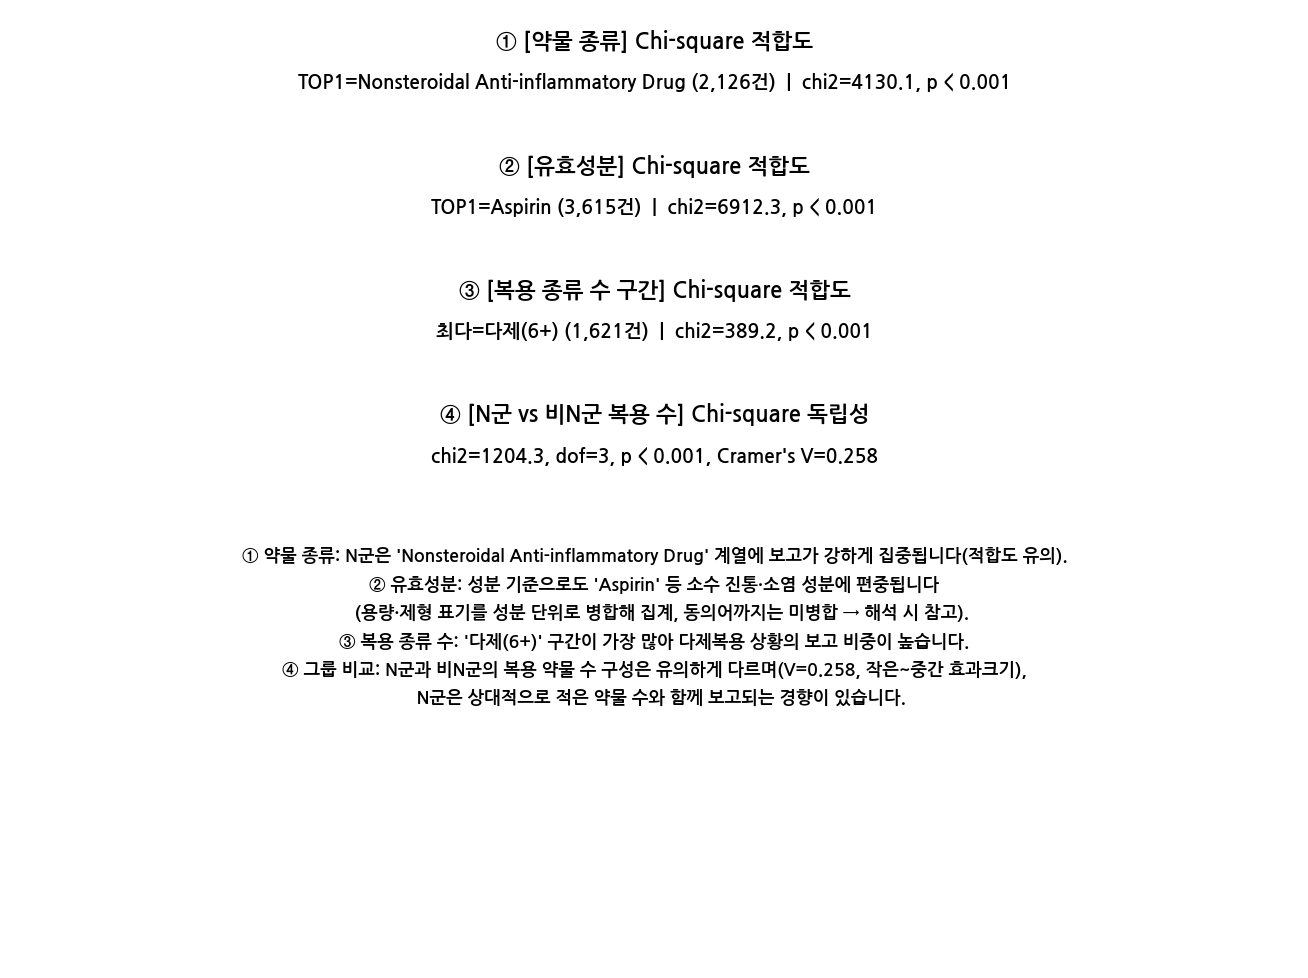

 ATC-N군 약물 분석 검정 요약
① 약리분류 chi2=4130.1 p < 0.001 | TOP1 Nonsteroidal Anti-inflammatory Drug
② 유효성분 chi2=6912.3 p < 0.001 | TOP1 Aspirin
③ 복용구간 chi2=389.2 p < 0.001 | 최다 다제(6+)
④ 그룹비교 chi2=1204.3 p < 0.001 V=0.258


In [14]:
# ---------------------------------------------------------------------
# [CELL 5] 통계검정 요약 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 9)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14.5,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.045-i*0.04, ln, ha='center', va='top',
                fontsize=12.5, fontweight='bold', transform=ax.transAxes)

block(0.98, "① [약물 종류] Chi-square 적합도", [
    f"TOP1={lab_pc[0]} ({top5_pc.values[0]:,}건)  |  chi2={chi2_pc:.1f}, {fmt_p(p_pc)}"])
block(0.85, "② [유효성분] Chi-square 적합도", [
    f"TOP1={top5_ing.index[0].title()} ({top5_ing.values[0]:,}건)  |  chi2={chi2_ing:.1f}, {fmt_p(p_ing)}"])
block(0.72, "③ [복용 종류 수 구간] Chi-square 적합도", [
    f"최다={cat_kr[cnt.values.argmax()]} ({cnt.max():,}건)  |  chi2={chi2_c3:.1f}, {fmt_p(p_c3)}"])
block(0.59, "④ [N군 vs 비N군 복용 수] Chi-square 독립성", [
    f"chi2={chi2_c4:.1f}, dof={dof_c4}, {fmt_p(p_c4)}, Cramer's V={cramer_v:.3f}"])

v_txt = "작은~중간" if cramer_v < 0.3 else "중간 이상"
interp = (
    f"① 약물 종류: N군은 '{lab_pc[0]}' 계열에 보고가 강하게 집중됩니다(적합도 유의).\n"
    f"② 유효성분: 성분 기준으로도 '{top5_ing.index[0].title()}' 등 소수 진통·소염 성분에 편중됩니다\n"
    "   (용량·제형 표기를 성분 단위로 병합해 집계, 동의어까지는 미병합 → 해석 시 참고).\n"
    f"③ 복용 종류 수: '{cat_kr[cnt.values.argmax()]}' 구간이 가장 많아 다제복용 상황의 보고 비중이 높습니다.\n"
    f"④ 그룹 비교: N군과 비N군의 복용 약물 수 구성은 유의하게 다르며(V={cramer_v:.3f}, {v_txt} 효과크기),\n"
    "   N군은 상대적으로 적은 약물 수와 함께 보고되는 경향이 있습니다."
)
ax.text(0.5, 0.44, interp, ha='center', va='top', fontsize=11.5,
        fontweight='bold', linespacing=1.75, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*60)
print(" ATC-N군 약물 분석 검정 요약")
print("="*60)
print(f"① 약리분류 chi2={chi2_pc:.1f} {fmt_p(p_pc)} | TOP1 {lab_pc[0]}")
print(f"② 유효성분 chi2={chi2_ing:.1f} {fmt_p(p_ing)} | TOP1 {top5_ing.index[0].title()}")
print(f"③ 복용구간 chi2={chi2_c3:.1f} {fmt_p(p_c3)} | 최다 {cat_kr[cnt.values.argmax()]}")
print(f"④ 그룹비교 chi2={chi2_c4:.1f} {fmt_p(p_c4)} V={cramer_v:.3f}")
print("="*60)

## **심각(serious) 비율**

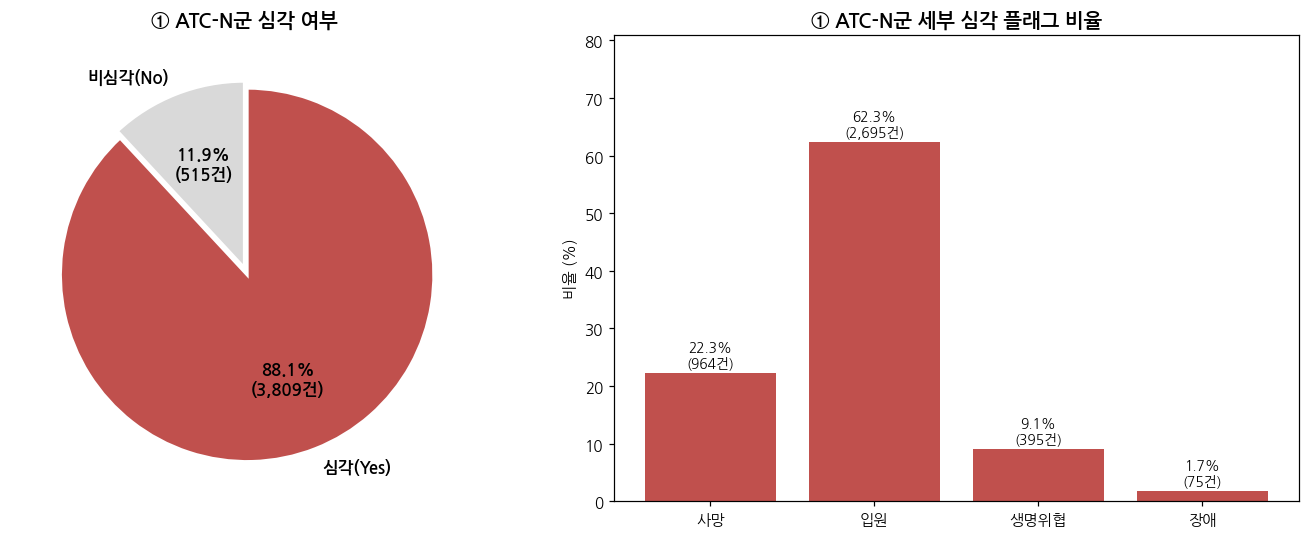

[① 심각 규모] serious Yes=3,809건 (88.1%) | 사망 964건(22.3%), 입원 2,695건(62.3%)


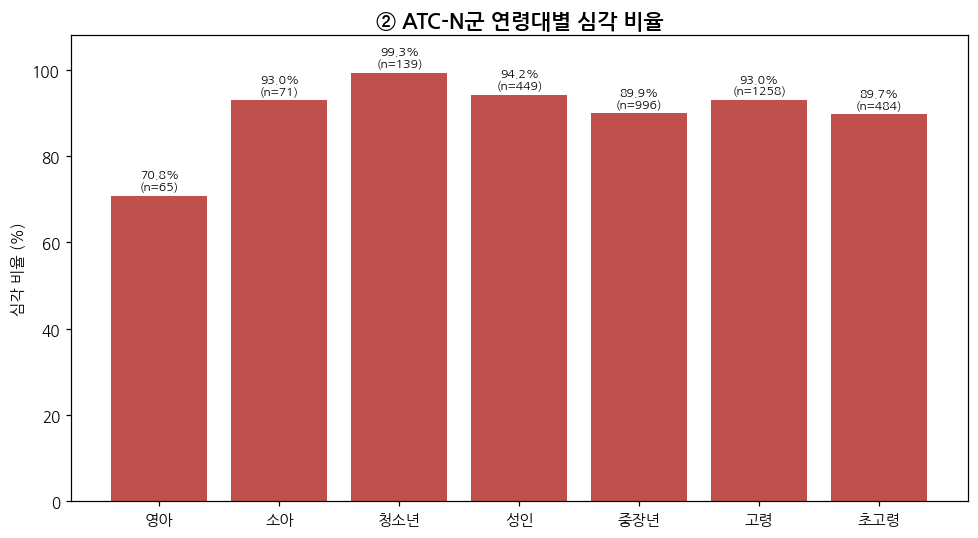

[② 연령대 × 심각] chi2=61.1, dof=6, p < 0.001 (기대빈도 최소 5.4)


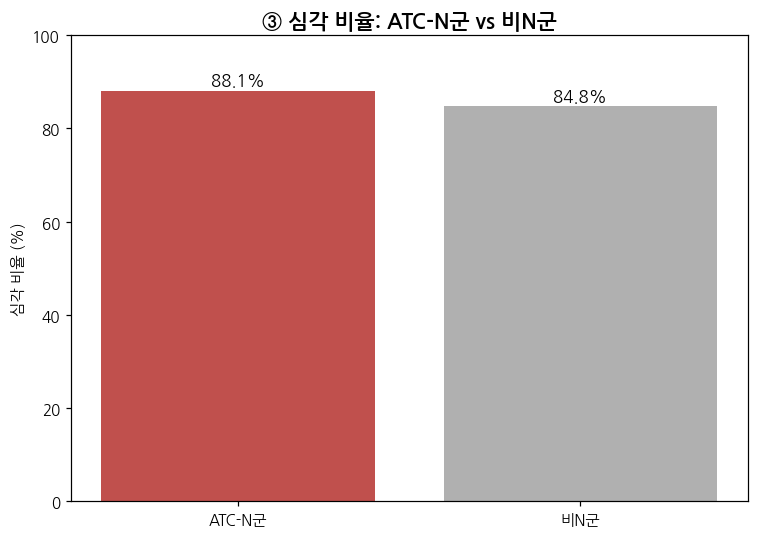

[③ 그룹 × 심각] N군 88.1% vs 비N군 84.8% | chi2=29.0, p < 0.001, Cramer's V=0.040


In [15]:

# ---------------------------------------------------------------------
# [CELL 1] serious 여부 + 세부 심각 플래그 (건수 & 비율)
# ---------------------------------------------------------------------
# CoT: 먼저 N군 부작용이 얼마나 심각한지 규모를 본다.
#   좌: serious Yes/No 건수.  우: 세부 플래그(사망/입원/생명위협/장애) 비율.

# Define RED color and serious_bin for correct execution
RED = '#c0504d'
df['serious_bin'] = (df['serious'] == 'Yes').astype(int)
N['serious_bin'] = (N['serious'] == 'Yes').astype(int)

ser = N['serious'].value_counts().reindex(['Yes', 'No']).fillna(0).astype(int)
flags = {'사망': 'is_fatal', '입원': 'is_hospitalized',
         '생명위협': 'is_life_threat', '장애': 'is_disabling'}
flag_cnt = {k: int((N[v] == True).sum()) for k, v in flags.items()}
flag_pct = {k: v/len(N)*100 for k, v in flag_cnt.items()}

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# 좌: 심각 여부 파이 차트 (Yes/No 비율 비교에 직관적)
ax[0].pie(ser.values, labels=['심각(Yes)', '비심각(No)'],
          colors=[RED, '#d9d9d9'], startangle=90, counterclock=False,
          autopct=lambda p: f'''{p:.1f}%
({int(round(p/100*ser.sum())):,}건)''',
          textprops={'fontsize': 11, 'fontweight': 'bold'},
          wedgeprops={'edgecolor': 'white', 'linewidth': 2},
          explode=(0.04, 0))
ax[0].set_title('① ATC-N군 심각 여부', fontweight='bold', fontsize=13)

b2 = ax[1].bar(list(flag_pct.keys()), list(flag_pct.values()), color=RED)
for b, k in zip(b2, flag_pct):
    ax[1].text(b.get_x()+b.get_width()/2, flag_pct[k]+0.5,
               f'''{flag_pct[k]:.1f}%
({flag_cnt[k]:,}건)''', ha='center', va='bottom', fontsize=9)
ax[1].set_title('① ATC-N군 세부 심각 플래그 비율', fontweight='bold', fontsize=13)
ax[1].set_ylabel('비율 (%)'); ax[1].set_ylim(0, max(flag_pct.values())*1.3)
plt.tight_layout(); plt.show()

print(f"[① 심각 규모] serious Yes={ser['Yes']:,}건 ({ser['Yes']/ser.sum()*100:.1f}%) | "
      f"사망 {flag_cnt['사망']:,}건({flag_pct['사망']:.1f}%), 입원 {flag_cnt['입원']:,}건({flag_pct['입원']:.1f}%)")


# ---------------------------------------------------------------------
# [CELL 2] 연령대별 심각 비율 (N군) — 카이제곱 독립성
# ---------------------------------------------------------------------
# CoT: N군 안에서 연령대에 따라 심각 비율이 다른가?
#   'Unknown' 제외. age_group × serious 카이제곱(기대빈도 5 이상 확인).
order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
         'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_kr = {'Infant(0-2)':'영아','Child(3-12)':'소아','Teen(13-18)':'청소년',
          'Adult(19-40)':'성인','Middle-Aged(41-65)':'중장년',
          'Senior(66-80)':'고령','Elderly(81+)':'초고령'}
Nc = N[N['age_group'] != 'Unknown']
g = Nc.groupby('age_group')['serious_bin'].agg(rate='mean', n='count').reindex(order).dropna()

ct_age = pd.crosstab(Nc['age_group'], Nc['serious_bin'])
chi2_a, p_a, dof_a, exp_a = stats.chi2_contingency(ct_age)

plt.figure(figsize=(9, 5))
bars = plt.bar([age_kr[i] for i in g.index], g['rate']*100, color=RED)
for b, (r, n) in zip(bars, zip(g['rate'], g['n'])):
    plt.text(b.get_x()+b.get_width()/2, r*100+0.8, f'''{r*100:.1f}%
(n={int(n)})''',
             ha='center', va='bottom', fontsize=8)
plt.title('② ATC-N군 연령대별 심각 비율', fontweight='bold', fontsize=14)
plt.ylabel('심각 비율 (%)'); plt.ylim(0, 108)
plt.tight_layout(); plt.show()
print(f"[② 연령대 × 심각] chi2={chi2_a:.1f}, dof={dof_a}, {fmt_p(p_a)} "
      f"(기대빈도 최소 {exp_a.min():.1f})")


# ---------------------------------------------------------------------
# [CELL 3] N군 vs 비N군 심각 비율 — 카이제곱 독립성 + Cramer's V
# ---------------------------------------------------------------------
# CoT: N군이 다른 약물군보다 더 심각하게 보고되는가?
#   group × serious 2x2 카이제곱 + 효과크기 Cramer's V.
ct_grp = pd.crosstab(df['is_N'], df['serious_bin'])
chi2_g, p_g, dof_g, _ = stats.chi2_contingency(ct_grp)
cramer_v = np.sqrt(chi2_g / (ct_grp.sum().sum() * (min(ct_grp.shape)-1)))
rate_N = df.loc[df['is_N'], 'serious_bin'].mean()*100
rate_NN = df.loc[~df['is_N'], 'serious_bin'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(['ATC-N군', '비N군'], [rate_N, rate_NN], color=[RED, '#b0b0b0'])
for b, v in zip(bars, [rate_N, rate_NN]):
    plt.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)
plt.title('③ 심각 비율: ATC-N군 vs 비N군', fontweight='bold', fontsize=14)
plt.ylabel('심각 비율 (%)'); plt.ylim(0, 100)
plt.tight_layout(); plt.show()
print(f"[③ 그룹 × 심각] N군 {rate_N:.1f}% vs 비N군 {rate_NN:.1f}% | "
      f"chi2={chi2_g:.1f}, {fmt_p(p_g)}, Cramer's V={cramer_v:.3f}")


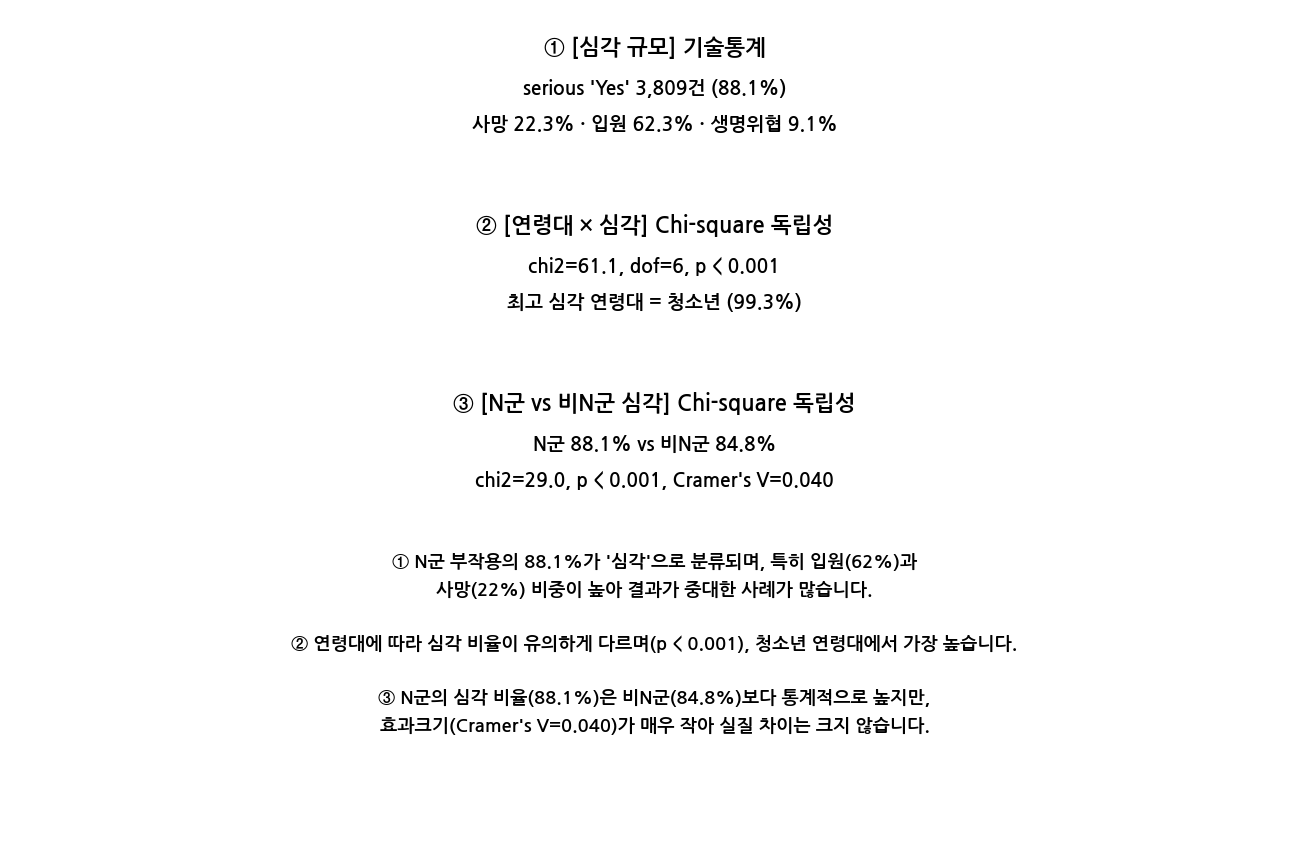

 ATC-N군 심각 정도 검정 요약
① 심각 Yes 3,809건 (88.1%) | 사망 22.3% 입원 62.3%
② 연령×심각 chi2=61.1 dof=6 p < 0.001 | 최고 청소년
③ 그룹×심각 N 88.1% vs 비N 84.8% chi2=29.0 p < 0.001 V=0.040


In [16]:

# ---------------------------------------------------------------------
# [CELL 4] 통계검정 요약 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14.5,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.05-i*0.043, ln, ha='center', va='top',
                fontsize=12.5, fontweight='bold', transform=ax.transAxes)

top_age = age_kr[g['rate'].idxmax()]
block(0.97, "① [심각 규모] 기술통계", [
    f"serious 'Yes' {ser['Yes']:,}건 ({ser['Yes']/ser.sum()*100:.1f}%)",
    f"사망 {flag_pct['사망']:.1f}% · 입원 {flag_pct['입원']:.1f}% · 생명위협 {flag_pct['생명위협']:.1f}%"])
block(0.76, "② [연령대 × 심각] Chi-square 독립성", [
    f"chi2={chi2_a:.1f}, dof={dof_a}, {fmt_p(p_a)}",
    f"최고 심각 연령대 = {top_age} ({g['rate'].max()*100:.1f}%)"])
block(0.55, "③ [N군 vs 비N군 심각] Chi-square 독립성", [
    f"N군 {rate_N:.1f}% vs 비N군 {rate_NN:.1f}%",
    f"chi2={chi2_g:.1f}, {fmt_p(p_g)}, Cramer's V={cramer_v:.3f}"])

v_txt = "매우 작아 실질 차이는 크지 않습니다" if cramer_v < 0.1 else "의미 있는 크기입니다"
interp = (
    f"① N군 부작용의 {ser['Yes']/ser.sum()*100:.1f}%가 '심각'으로 분류되며, 특히 입원"
    f"({flag_pct['입원']:.0f}%)과\n사망({flag_pct['사망']:.0f}%) 비중이 높아 결과가 중대한 사례가 많습니다.\n\n"
    f"② 연령대에 따라 심각 비율이 유의하게 다르며({fmt_p(p_a)}), {top_age} 연령대에서 가장 높습니다.\n\n"
    f"③ N군의 심각 비율({rate_N:.1f}%)은 비N군({rate_NN:.1f}%)보다 통계적으로 높지만,\n"
    f"효과크기(Cramer's V={cramer_v:.3f})가 {v_txt}."
)
ax.text(0.5, 0.36, interp, ha='center', va='top', fontsize=12,
        fontweight='bold', linespacing=1.7, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*60)
print(" ATC-N군 심각 정도 검정 요약")
print("="*60)
print(f"① 심각 Yes {ser['Yes']:,}건 ({ser['Yes']/ser.sum()*100:.1f}%) | 사망 {flag_pct['사망']:.1f}% 입원 {flag_pct['입원']:.1f}%")
print(f"② 연령×심각 chi2={chi2_a:.1f} dof={dof_a} {fmt_p(p_a)} | 최고 {top_age}")
print(f"③ 그룹×심각 N {rate_N:.1f}% vs 비N {rate_NN:.1f}% chi2={chi2_g:.1f} {fmt_p(p_g)} V={cramer_v:.3f}")
print("="*60)

## **시계열**

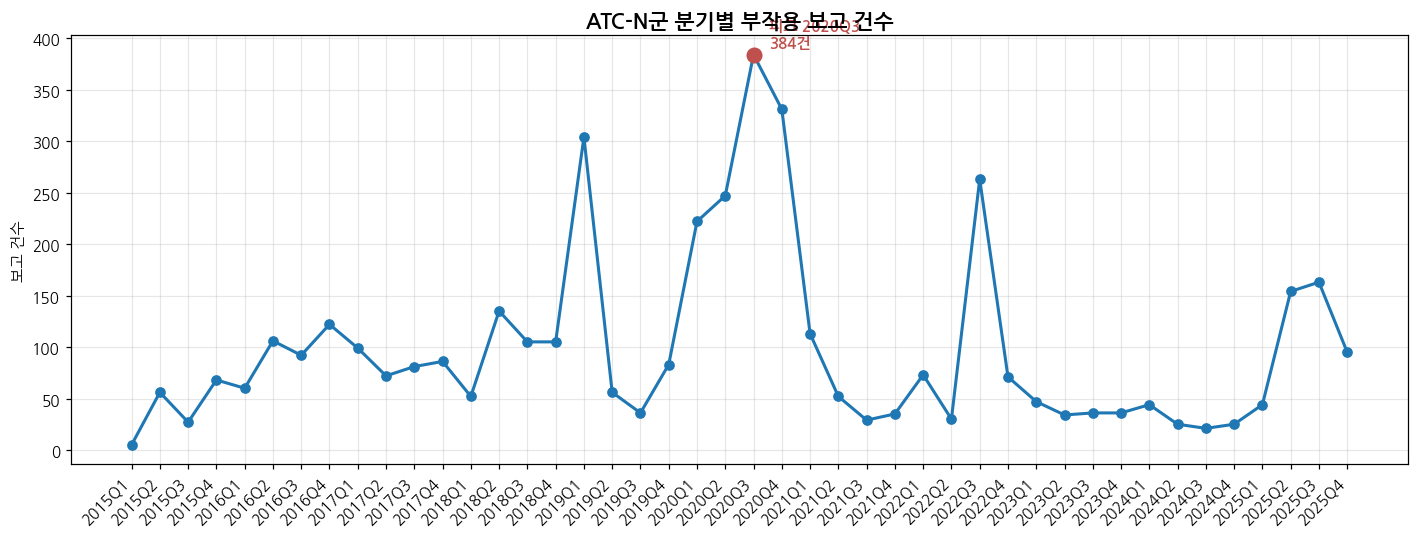

[시계열 추세] Spearman rho=-0.027, p = 0.937
  → 단조추세 없음(특정 시점 급증형)
  피크 분기=2020Q3 (384건), 피크 연도=2020 (1,184건)
  전체 기간: 2015Q1 ~ 2025Q4, 총 4,324건


In [17]:

# ---------------------------------------------------------------------
# 분기별 시계열
# ---------------------------------------------------------------------
# CoT: receive_date를 분기로 묶어 건수 추이. NaT(날짜결측) 제외.
N['dt'] = pd.to_datetime(N['receive_date'], errors='coerce')
ts = N.dropna(subset=['dt']).set_index('dt').resample('QE').size()
ts.index = ts.index.to_period('Q').astype(str)

plt.figure(figsize=(13, 5))
plt.plot(ts.index, ts.values, marker='o', color=BLUE, lw=2)
peak = ts.idxmax()
plt.scatter([peak], [ts.max()], color=RED, zorder=5, s=90)
plt.annotate(f'피크 {peak}\n{ts.max():,}건', (peak, ts.max()),
             textcoords='offset points', xytext=(10, 5), fontsize=10, color=RED, fontweight='bold')
plt.title('ATC-N군 분기별 부작용 보고 건수', fontweight='bold', fontsize=14)
plt.ylabel('보고 건수'); plt.xticks(rotation=45, ha='right')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
# 추세 검정 (Spearman 순위상관: 연도 vs 연간 건수)
# ---------------------------------------------------------------------
# CoT: "시간이 갈수록 증가/감소하는 단조추세가 있는가?"를 본다.
#   연도 단위로 집계해 Spearman rho. (분기엔 계절성 노이즈가 커 연 단위가 안정적)
#   유의하지 않으면 '단조추세 없음 + 특정 시점 급증' 구조로 해석.
yr = N.dropna(subset=['dt']).groupby(N['dt'].dt.year).size()
rho, p_tr = stats.spearmanr(yr.index, yr.values)
print(f"[시계열 추세] Spearman rho={rho:.3f}, {fmt_p(p_tr)}")
print(f"  → {'유의한 단조추세 있음' if p_tr < 0.05 else '단조추세 없음(특정 시점 급증형)'}")
print(f"  피크 분기={peak} ({ts.max():,}건), 피크 연도={yr.idxmax()} ({yr.max():,}건)")
print(f"  전체 기간: {ts.index[0]} ~ {ts.index[-1]}, 총 {ts.sum():,}건")



## **이전 질환**

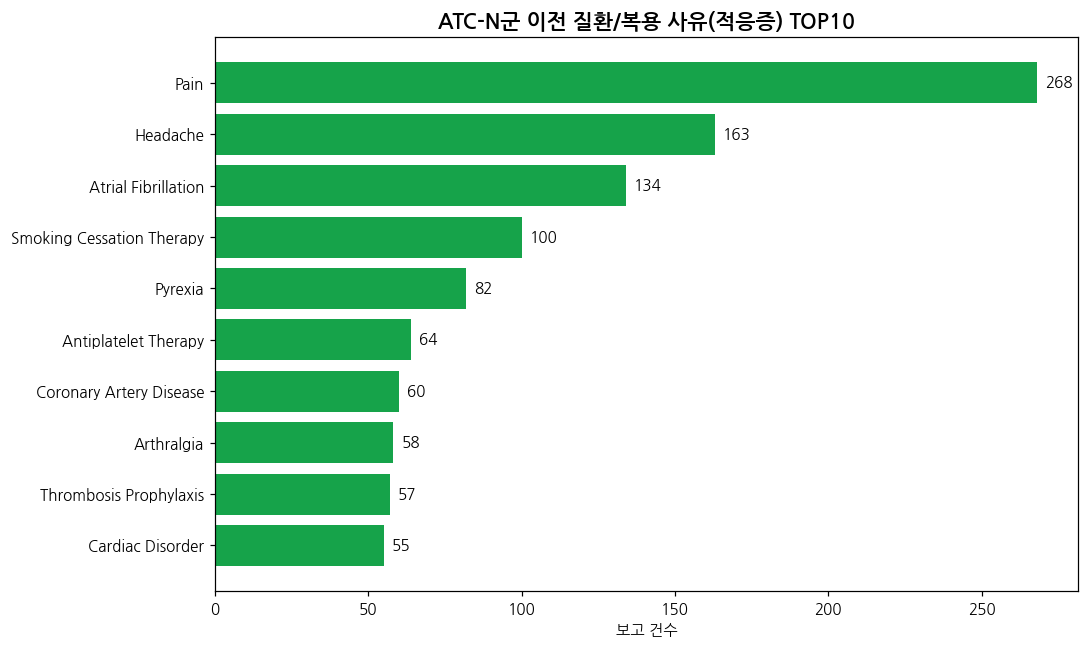

In [18]:

# ---------------------------------------------------------------------
# 적응증(복용 사유) TOP10
# ---------------------------------------------------------------------
# CoT: drug_indication은 '; ' 다중값. explode 후, 'Unknown' 및
#   'Product Used For Unknown Indication'(사실상 결측) 제거하고 건수 집계.
GREEN = '#16a34a'
ind = N['drug_indication'].dropna().astype(str).str.split(';').explode().str.strip()
ind = ind[~ind.str.lower().str.contains('unknown')]
top10 = ind.value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10.index[::-1], top10.values[::-1], color=GREEN)
for b, v in zip(bars, top10.values[::-1]):
    plt.text(v+max(top10.values)*0.01, b.get_y()+b.get_height()/2, f'{v:,}',
             va='center', fontsize=10)
plt.title('ATC-N군 이전 질환/복용 사유(적응증) TOP10', fontweight='bold', fontsize=14)
plt.xlabel('보고 건수'); plt.tight_layout(); plt.show()


In [19]:


# ---------------------------------------------------------------------
# 편중 검정 (카이제곱 적합도, TOP5 기준)
# ---------------------------------------------------------------------
# CoT: 상위 사유가 균등한지(귀무) vs 특정 질환에 몰리는지 적합도 검정.
top5 = top10.head(5)
chi2, p = stats.chisquare(top5.values)
print(f"[적응증 TOP5 적합도] chi2={chi2:.1f}, {fmt_p(p)} "
      f"→ {'특정 질환/증상에 편중' if p < 0.05 else '고른 분포'}")
print(f"  최다 사유 = {top10.index[0]} ({top10.values[0]:,}건)")
print(f"  유효 적응증 언급 총 {ind.value_counts().sum():,}건 (Unknown류 제외)")

[적응증 TOP5 적합도] chi2=143.7, p < 0.001 → 특정 질환/증상에 편중
  최다 사유 = Pain (268건)
  유효 적응증 언급 총 1,983건 (Unknown류 제외)


## **부작용 반응**

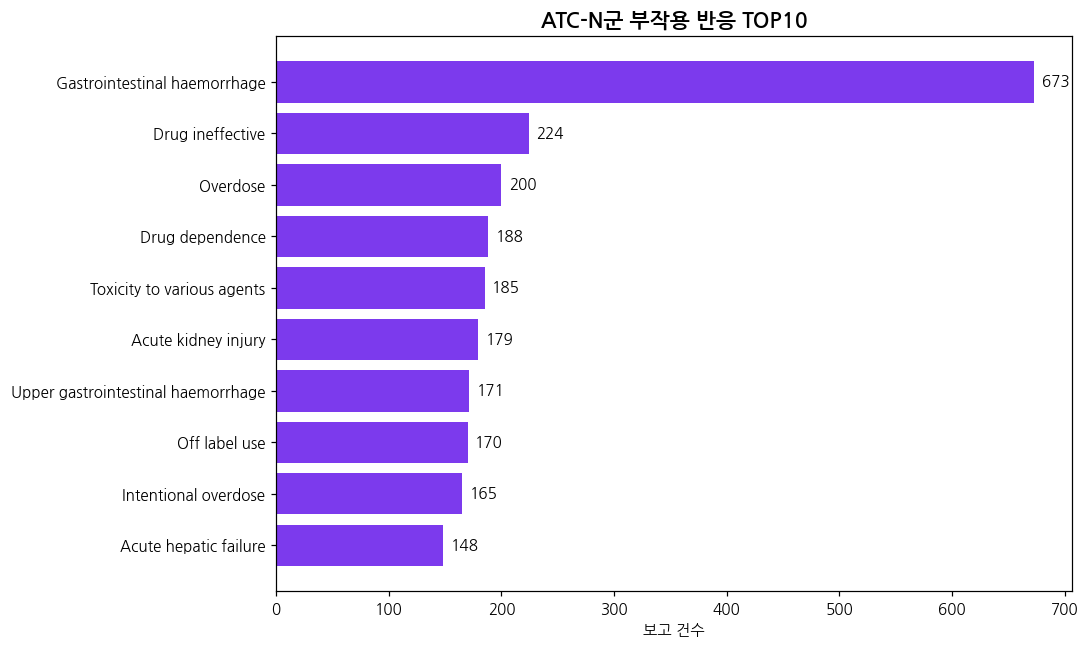

In [20]:

# ---------------------------------------------------------------------
# 부작용 반응 TOP10
# ---------------------------------------------------------------------
# CoT: reactions는 '; ' 다중값. explode 후 Unknown/공백 제거하고 건수 집계.
rx = N['reactions'].dropna().astype(str).str.split(';').explode().str.strip()
rx = rx[~rx.str.lower().isin(['unknown', ''])]
top10 = rx.value_counts().head(10)

# Define PURPLE color
PURPLE = C[4]

plt.figure(figsize=(10, 6))
bars = plt.barh(top10.index[::-1], top10.values[::-1], color=PURPLE)
for b, v in zip(bars, top10.values[::-1]):
    plt.text(v+max(top10.values)*0.01, b.get_y()+b.get_height()/2, f'{v:,}',
             va='center', fontsize=10)
plt.title('ATC-N군 부작용 반응 TOP10', fontweight='bold', fontsize=14)
plt.xlabel('보고 건수'); plt.tight_layout(); plt.show()


In [21]:

# ---------------------------------------------------------------------
# 편중 검정 (카이제곱 적합도, TOP5 기준)
# ---------------------------------------------------------------------
# CoT: 상위 반응이 균등한지 vs 특정 반응에 몰리는지 적합도 검정.
top5 = top10.head(5)
chi2, p = stats.chisquare(top5.values)
print(f"[반응 TOP5 적합도] chi2={chi2:.1f}, {fmt_p(p)} "
      f"→ {'특정 반응에 편중' if p < 0.05 else '고른 분포'}")
print(f"  최다 반응 = {top10.index[0]} ({top10.values[0]:,}건)")
print(f"  반응 언급 총 {rx.value_counts().sum():,}건 (Unknown 제외)")

[반응 TOP5 적합도] chi2=613.9, p < 0.001 → 특정 반응에 편중
  최다 반응 = Gastrointestinal haemorrhage (673건)
  반응 언급 총 11,652건 (Unknown 제외)


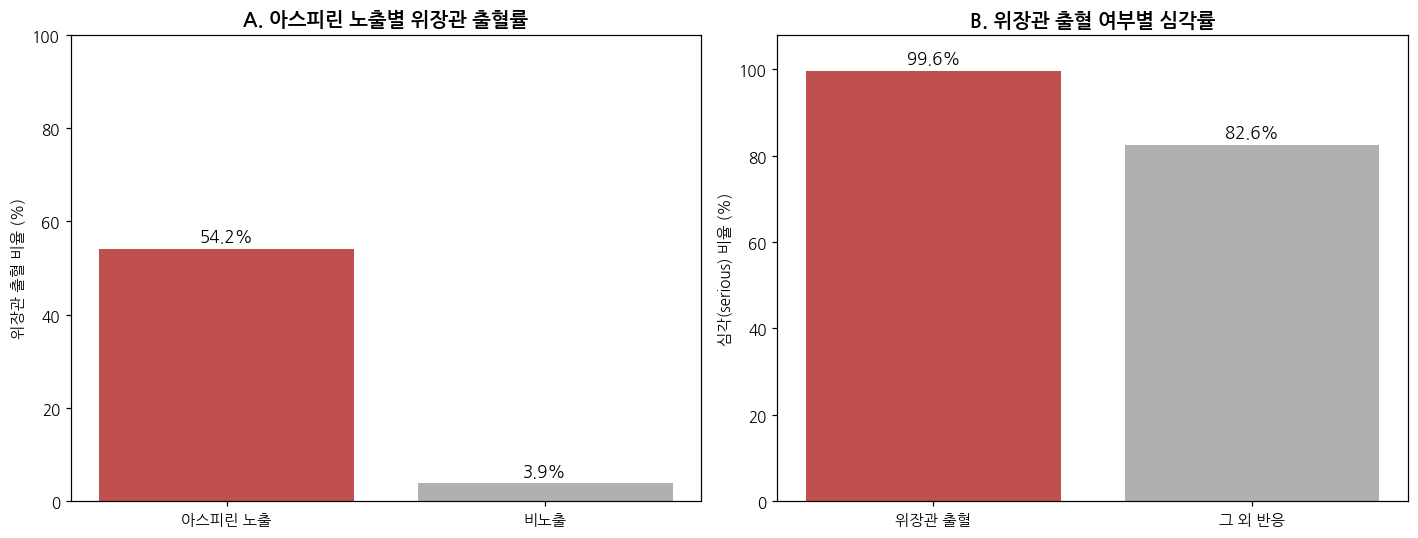

[검정A 아스피린×위장관출혈] chi2=1224.0, p < 0.001, Cramer's V=0.532
  위장관 출혈률: 아스피린 노출 54.2% vs 비노출 3.9%
[검정B 위장관출혈×심각] chi2=262.0, p < 0.001, Cramer's V=0.246
  심각률: 위장관 출혈 99.6% vs 그 외 82.6%


In [22]:
# =====================================================================
#  [코드 4] Claude 판단 추가 분석 — 아스피린 → 위장관 출혈 → 심각도 연결고리
#
#  선정 이유(CoT):
#   앞 분석에서 N군의 (1)최다 유효성분=아스피린, (2)최다 부작용반응=위장관
#   출혈, (3)심각도 88%가 각각 나왔다. 이 셋은 따로 있는 사실이 아니라 하나의
#   임상 스토리로 연결될 가능성이 크다: "아스피린/NSAID가 위장관 출혈을 일으키고,
#   그 출혈이 심각 결과로 이어진다." 이를 두 개의 카이제곱으로 검증한다.
#     검정A: 아스피린 노출 × 위장관출혈  (연관 존재?)
#     검정B: 위장관출혈 × 심각여부       (출혈이 중증과 연결?)
#
#  방법론: CoT + Self-Refine. 건수 기준(심각은 비율 병행).
# =====================================================================


# --- (df 가 앞 셀에서 로드돼 있으면 아래 2줄 생략) ---
# FILE = "FDA_adverse_events_final_중복값제거_듀플제거___몸무게_결측_제거.csv"
# df = pd.read_csv(FILE)


# ---------------------------------------------------------------------
# 파생 플래그 (Self-Refine: 텍스트 정규화)
# ---------------------------------------------------------------------
# CoT: 세 개의 이진 플래그를 만든다.
#   gi_bleed : 반응에 출혈(haemorrhage/hemorrhage/bleed) 포함
#   aspirin  : 의심약물에 아스피린/아세틸살리실산 포함
#   serious  : serious == 'Yes'
N['gi_bleed'] = N['reactions'].fillna('').str.contains('haemorrhage|hemorrhage|bleed', case=False)
N['aspirin']  = N['suspect_drug'].fillna('').str.contains('aspirin|acetylsalicylic', case=False)
N['serious_bin'] = (N['serious'] == 'Yes').astype(int)


# ---------------------------------------------------------------------
# 검정 A: 아스피린 노출 × 위장관 출혈
# ---------------------------------------------------------------------
# CoT: 아스피린 노출군과 비노출군의 위장관 출혈률 비교 (2x2 카이제곱 + Cramer's V).
ctA = pd.crosstab(N['aspirin'], N['gi_bleed'])
chi2A, pA, dofA, _ = stats.chi2_contingency(ctA)
vA = np.sqrt(chi2A / (ctA.sum().sum() * (min(ctA.shape)-1)))
rate_asp = N.loc[N['aspirin'], 'gi_bleed'].mean()*100
rate_non = N.loc[~N['aspirin'], 'gi_bleed'].mean()*100

# 검정 B: 위장관 출혈 × 심각 여부
ctB = pd.crosstab(N['gi_bleed'], N['serious_bin'])
chi2B, pB, dofB, _ = stats.chi2_contingency(ctB)
vB = np.sqrt(chi2B / (ctB.sum().sum() * (min(ctB.shape)-1)))
sev_bleed = N.loc[N['gi_bleed'], 'serious_bin'].mean()*100
sev_nobl  = N.loc[~N['gi_bleed'], 'serious_bin'].mean()*100


# ---------------------------------------------------------------------
# 그래프: 두 검정을 나란히
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# A: 아스피린 노출 여부별 위장관 출혈률
b1 = ax[0].bar(['아스피린 노출', '비노출'], [rate_asp, rate_non], color=[RED, '#b0b0b0'])
for b, v in zip(b1, [rate_asp, rate_non]):
    ax[0].text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)
ax[0].set_title('A. 아스피린 노출별 위장관 출혈률', fontweight='bold', fontsize=13)
ax[0].set_ylabel('위장관 출혈 비율 (%)'); ax[0].set_ylim(0, 100)

# B: 위장관 출혈 여부별 심각률
b2 = ax[1].bar(['위장관 출혈', '그 외 반응'], [sev_bleed, sev_nobl], color=[RED, '#b0b0b0'])
for b, v in zip(b2, [sev_bleed, sev_nobl]):
    ax[1].text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)
ax[1].set_title('B. 위장관 출혈 여부별 심각률', fontweight='bold', fontsize=13)
ax[1].set_ylabel('심각(serious) 비율 (%)'); ax[1].set_ylim(0, 108)
plt.tight_layout(); plt.show()

print(f"[검정A 아스피린×위장관출혈] chi2={chi2A:.1f}, {fmt_p(pA)}, Cramer's V={vA:.3f}")
print(f"  위장관 출혈률: 아스피린 노출 {rate_asp:.1f}% vs 비노출 {rate_non:.1f}%")
print(f"[검정B 위장관출혈×심각] chi2={chi2B:.1f}, {fmt_p(pB)}, Cramer's V={vB:.3f}")
print(f"  심각률: 위장관 출혈 {sev_bleed:.1f}% vs 그 외 {sev_nobl:.1f}%")



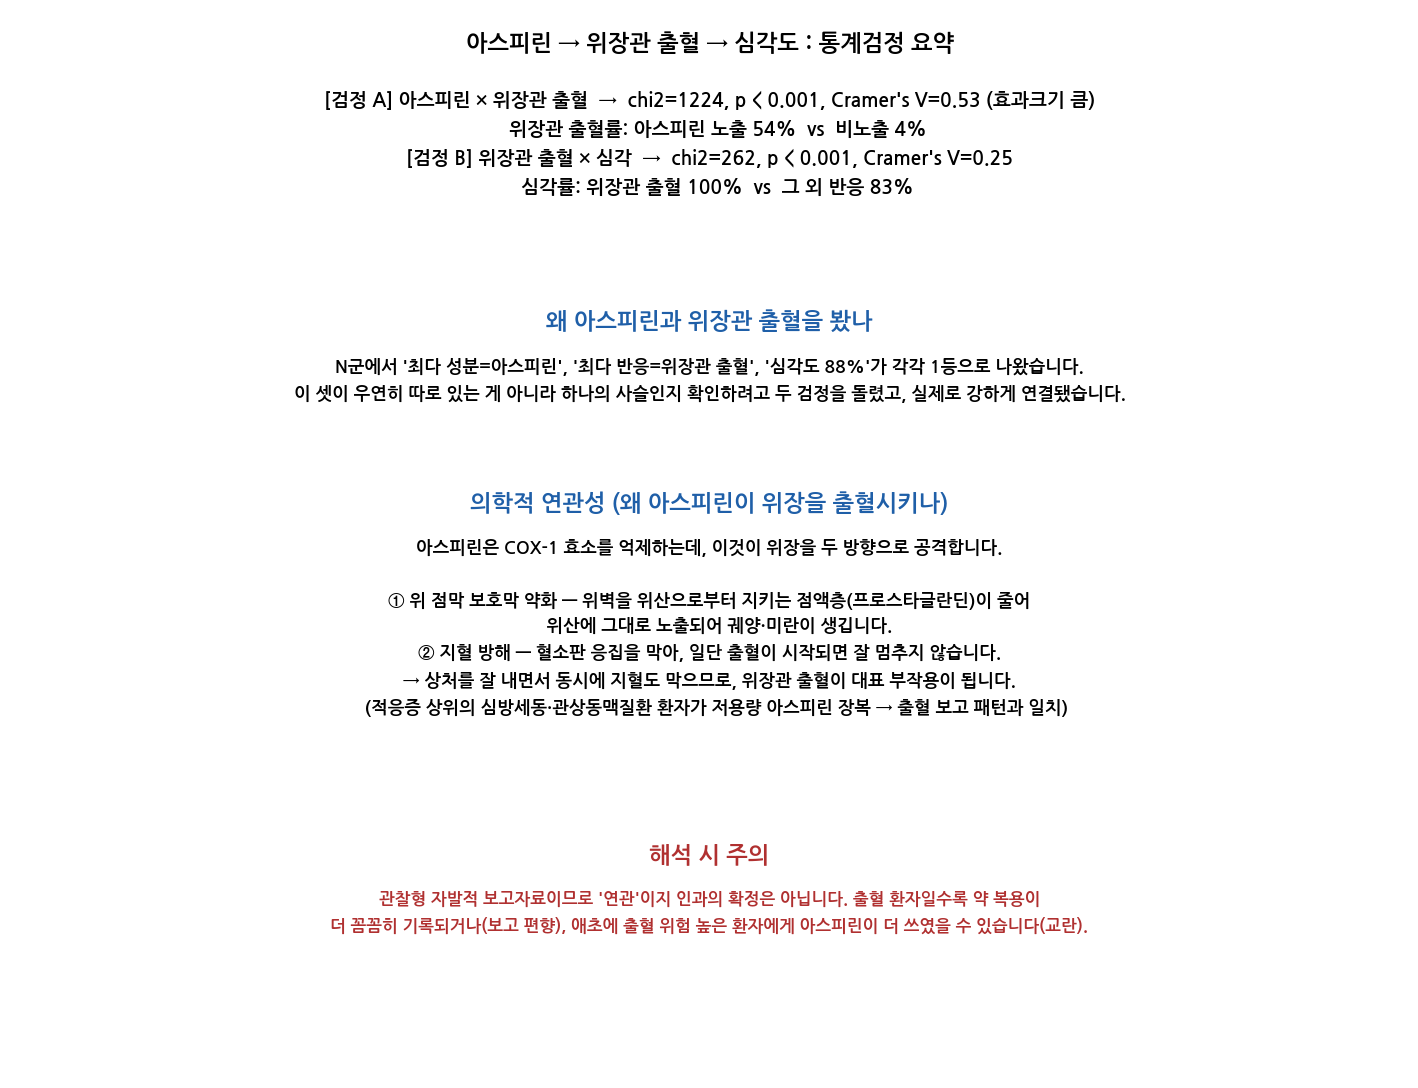

 [Claude 판단 분석] 아스피린 → 위장관 출혈 → 심각도
A 아스피린×출혈 chi2=1224.0 p < 0.001 V=0.532 (54.2% vs 3.9%)
B 출혈×심각    chi2=262.0 p < 0.001 V=0.246 (99.6% vs 82.6%)


In [23]:

# ---------------------------------------------------------------------
# 통계검정 요약 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 10)); ax.axis('off')

def section_title(y, text, color='black'):
    ax.text(0.5, y, text, ha='center', va='top', fontsize=15,
            fontweight='bold', color=color, transform=ax.transAxes)

def body(y, text, size=12, color='black'):
    ax.text(0.5, y, text, ha='center', va='top', fontsize=size,
            fontweight='bold', color=color, linespacing=1.65, transform=ax.transAxes)

# ── 검정값 (요약) ──
section_title(0.98, "아스피린 → 위장관 출혈 → 심각도 : 통계검정 요약")
body(0.925,
     f"[검정 A] 아스피린 × 위장관 출혈  →  chi2={chi2A:.0f}, {fmt_p(pA)}, Cramer's V={vA:.2f} (효과크기 큼)\n"
     f"   위장관 출혈률: 아스피린 노출 {rate_asp:.0f}%  vs  비노출 {rate_non:.0f}%\n"
     f"[검정 B] 위장관 출혈 × 심각  →  chi2={chi2B:.0f}, {fmt_p(pB)}, Cramer's V={vB:.2f}\n"
     f"   심각률: 위장관 출혈 {sev_bleed:.0f}%  vs  그 외 반응 {sev_nobl:.0f}%",
     size=12.5)

# ── 왜 이 조합을 봤나 ──
section_title(0.72, "왜 아스피린과 위장관 출혈을 봤나", color='#1f5fa8')
body(0.675,
     "N군에서 '최다 성분=아스피린', '최다 반응=위장관 출혈', '심각도 88%'가 각각 1등으로 나왔습니다.\n"
     "이 셋이 우연히 따로 있는 게 아니라 하나의 사슬인지 확인하려고 두 검정을 돌렸고, 실제로 강하게 연결됐습니다.",
     size=11.5)

# ── 의학적 기전 ──
section_title(0.55, "의학적 연관성 (왜 아스피린이 위장을 출혈시키나)", color='#1f5fa8')
body(0.505,
     "아스피린은 COX-1 효소를 억제하는데, 이것이 위장을 두 방향으로 공격합니다.\n\n"
     "① 위 점막 보호막 약화 — 위벽을 위산으로부터 지키는 점액층(프로스타글란딘)이 줄어\n"
     "    위산에 그대로 노출되어 궤양·미란이 생깁니다.\n"
     "② 지혈 방해 — 혈소판 응집을 막아, 일단 출혈이 시작되면 잘 멈추지 않습니다.\n"
     "→ 상처를 잘 내면서 동시에 지혈도 막으므로, 위장관 출혈이 대표 부작용이 됩니다.\n"
     "   (적응증 상위의 심방세동·관상동맥질환 환자가 저용량 아스피린 장복 → 출혈 보고 패턴과 일치)",
     size=11.5)

# ── 주의점 ──
section_title(0.22, "해석 시 주의", color='#b03030')
body(0.175,
     "관찰형 자발적 보고자료이므로 '연관'이지 인과의 확정은 아닙니다. 출혈 환자일수록 약 복용이\n"
     "더 꼼꼼히 기록되거나(보고 편향), 애초에 출혈 위험 높은 환자에게 아스피린이 더 쓰였을 수 있습니다(교란).",
     size=11, color='#b03030')

plt.tight_layout(); plt.show()

print("="*60)
print(" [Claude 판단 분석] 아스피린 → 위장관 출혈 → 심각도")
print("="*60)
print(f"A 아스피린×출혈 chi2={chi2A:.1f} {fmt_p(pA)} V={vA:.3f} ({rate_asp:.1f}% vs {rate_non:.1f}%)")
print(f"B 출혈×심각    chi2={chi2B:.1f} {fmt_p(pB)} V={vB:.3f} ({sev_bleed:.1f}% vs {sev_nobl:.1f}%)")
print("="*60)

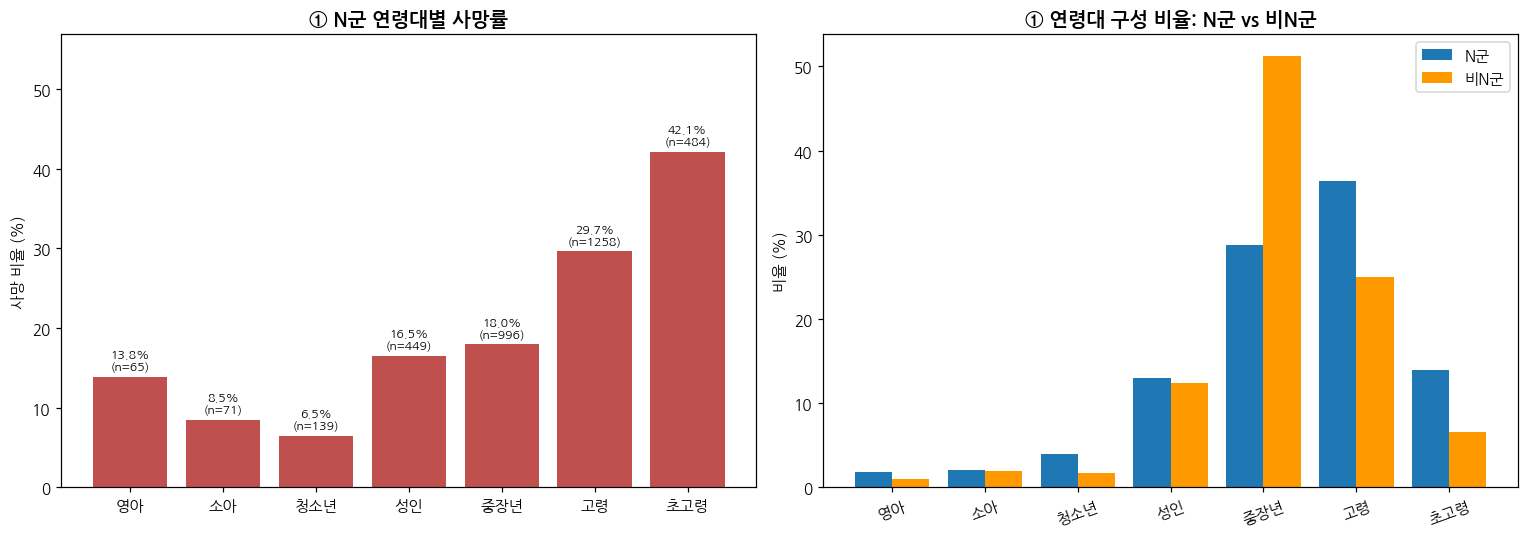

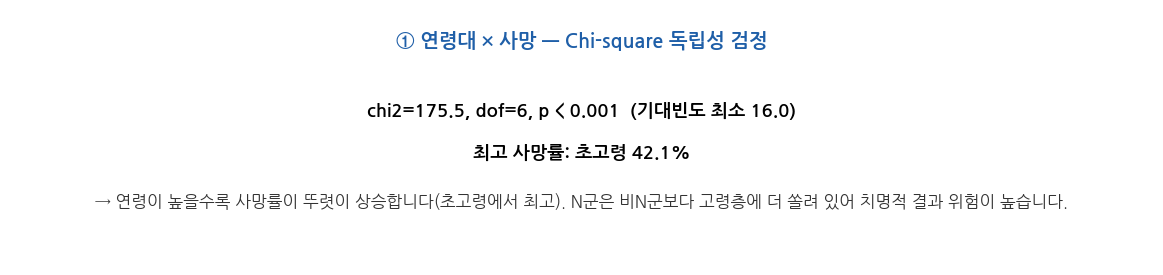

In [24]:
# =====================================================================
#  ATC-N군 심화 분석 5종 + 통계검정
#   (1) 연령대 × 사망 (N군)  +  비N군 연령대 분포 비교
#   (2) 성별 × 사망 (N군)
#   (3) 약물 수 × 심각성 (N군 vs 비N군)
#   (4) 약물 수 범주 × 치명성(사망) (N군 vs 비N군)
#   (5) 분기별 추세 (N군)
#
# =====================================================================
#  ATC-N군 심화 분석 5종 + 통계검정
#   (1) 연령대 × 사망 (N군)  +  비N군 연령대 분포 비교
#   (2) 성별 × 사망 (N군)
#   (3) 약물 수 × 심각성 (N군 vs 비N군)
#   (4) 약물 수 범주 × 치명성(사망) (N군 vs 비N군)
#   (5) 분기별 추세 (N군)
#
#  방법론: CoT(검정 선택 근거 주석) + Self-Refine(정제→계산→검증)
#  ※ 사망/심각은 '비율' 병행, 그 외는 건수 기준.
# =====================================================================

df['is_N'] = (df['WHO_ATC'] == 'N')
df['fatal'] = (df['is_fatal'] == True).astype(int)
df['serious_bin'] = (df['serious'] == 'Yes').astype(int)
N  = df[df['is_N']].copy()
NN = df[~df['is_N']].copy()
BLUE, ORANGE, RED = '#1f77b4', '#ff9900', '#c0504d'
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def stat_card(title, stat_lines, insight):
    """그래프 직후에 붙이는 검정 통계 + 인사이트 미니 카드."""
    fig, ax = plt.subplots(figsize=(11, 2.6)); ax.axis('off')
    ax.text(0.5, 0.92, title, ha='center', va='top', fontsize=13,
            fontweight='bold', color='#1f5fa8', transform=ax.transAxes)
    for i, ln in enumerate(stat_lines):
        ax.text(0.5, 0.64-i*0.17, ln, ha='center', va='top', fontsize=12,
                fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.62-len(stat_lines)*0.17, "→ " + insight, ha='center', va='top',
            fontsize=11, color='#333333', linespacing=1.5, transform=ax.transAxes)
    plt.tight_layout(); plt.show()

age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_kr = {'Infant(0-2)':'영아','Child(3-12)':'소아','Teen(13-18)':'청소년',
          'Adult(19-40)':'성인','Middle-Aged(41-65)':'중장년',
          'Senior(66-80)':'고령','Elderly(81+)':'초고령'}
cat_order = ['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)']
cat_kr = ['단일','2-3종','4-5종','다제(6+)']


# ---------------------------------------------------------------------
# [CELL 1] 연령대 × 사망 (N군) + 비N군 연령대 분포 비교
# ---------------------------------------------------------------------
# CoT: 좌 - N군 연령대별 '사망률'(치명성이 연령과 관련 있는지, 카이제곱).
#      우 - N군 vs 비N군의 연령대 '구성 비율'(어느 연령에 보고가 쏠리는지 비교).
Nc  = N[N['age_group'] != 'Unknown']
NNc = NN[NN['age_group'] != 'Unknown']
fatal_rate = Nc.groupby('age_group')['fatal'].agg(rate='mean', n='count').reindex(age_order).dropna()
ct_af = pd.crosstab(Nc['age_group'], Nc['fatal'])
chi2_af, p_af, dof_af, exp_af = stats.chi2_contingency(ct_af)

dist_N  = (Nc['age_group'].value_counts(normalize=True)*100).reindex(age_order).fillna(0)
dist_NN = (NNc['age_group'].value_counts(normalize=True)*100).reindex(age_order).fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
kr = [age_kr[i] for i in fatal_rate.index]
b1 = ax[0].bar(kr, fatal_rate['rate']*100, color=RED)
for b, (r, n) in zip(b1, zip(fatal_rate['rate'], fatal_rate['n'])):
    ax[0].text(b.get_x()+b.get_width()/2, r*100+0.6, f'{r*100:.1f}%\n(n={int(n)})',
               ha='center', va='bottom', fontsize=8)
ax[0].set_title('① N군 연령대별 사망률', fontweight='bold', fontsize=13)
ax[0].set_ylabel('사망 비율 (%)'); ax[0].set_ylim(0, max(fatal_rate['rate']*100)*1.35)

x = np.arange(len(age_order)); w = 0.4
ax[1].bar(x-w/2, dist_N.values,  w, color=BLUE,   label='N군')
ax[1].bar(x+w/2, dist_NN.values, w, color=ORANGE, label='비N군')
ax[1].set_xticks(x); ax[1].set_xticklabels([age_kr[i] for i in age_order], rotation=20)
ax[1].set_title('① 연령대 구성 비율: N군 vs 비N군', fontweight='bold', fontsize=13)
ax[1].set_ylabel('비율 (%)'); ax[1].legend()
plt.tight_layout(); plt.show()

stat_card("① 연령대 × 사망 — Chi-square 독립성 검정",
    [f"chi2={chi2_af:.1f}, dof={dof_af}, {fmt_p(p_af)}  (기대빈도 최소 {exp_af.min():.1f})",
     f"최고 사망률: {age_kr[fatal_rate['rate'].idxmax()]} {fatal_rate['rate'].max()*100:.1f}%"],
    "연령이 높을수록 사망률이 뚜렷이 상승합니다(초고령에서 최고). "
    "N군은 비N군보다 고령층에 더 쏠려 있어 치명적 결과 위험이 높습니다.")




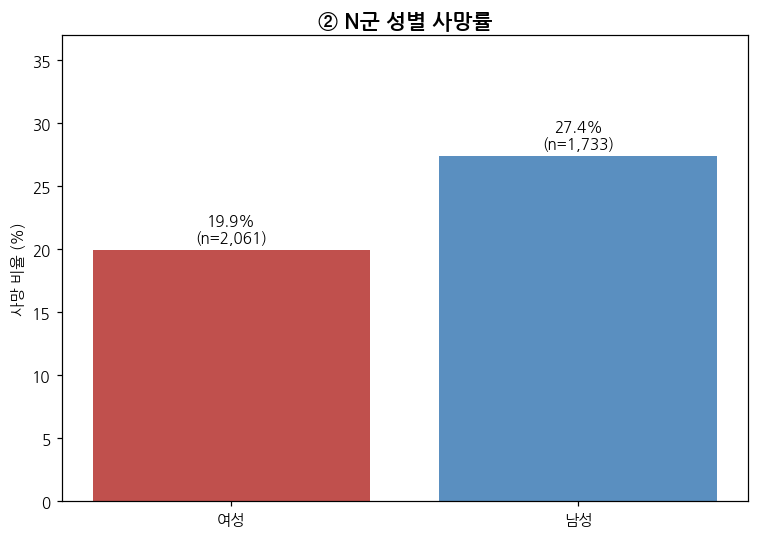

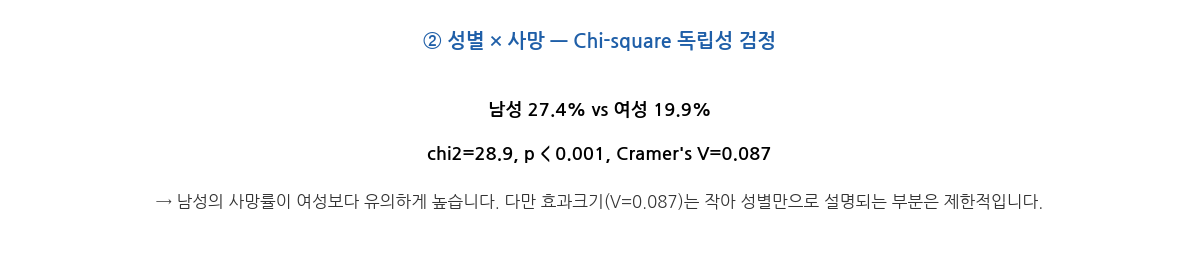

In [25]:
# ---------------------------------------------------------------------
# [CELL 2] 성별 × 사망 (N군)
# ---------------------------------------------------------------------
# CoT: 남/여 사망률 차이 검정 (Unknown 제외, 2x2 카이제곱 + Cramer's V).
s = N[N['patient_sex'].isin(['Male','Female'])]
sex_kr = {'Female':'여성','Male':'남성'}
fr = s.groupby('patient_sex')['fatal'].agg(rate='mean', n='count')
ct_sf = pd.crosstab(s['patient_sex'], s['fatal'])
chi2_sf, p_sf, dof_sf, _ = stats.chi2_contingency(ct_sf)
v_sf = np.sqrt(chi2_sf / (ct_sf.sum().sum() * (min(ct_sf.shape)-1)))

plt.figure(figsize=(7, 5))
bars = plt.bar([sex_kr[i] for i in fr.index], fr['rate']*100, color=[RED, '#5a8fc0'])
for b, (r, n) in zip(bars, zip(fr['rate'], fr['n'])):
    plt.text(b.get_x()+b.get_width()/2, r*100+0.4, f'{r*100:.1f}%\n(n={int(n):,})',
             ha='center', va='bottom', fontsize=10)
plt.title('② N군 성별 사망률', fontweight='bold', fontsize=14)
plt.ylabel('사망 비율 (%)'); plt.ylim(0, max(fr['rate']*100)*1.35)
plt.tight_layout(); plt.show()

stat_card("② 성별 × 사망 — Chi-square 독립성 검정",
    [f"남성 {fr.loc['Male','rate']*100:.1f}% vs 여성 {fr.loc['Female','rate']*100:.1f}%",
     f"chi2={chi2_sf:.1f}, {fmt_p(p_sf)}, Cramer's V={v_sf:.3f}"],
    "남성의 사망률이 여성보다 유의하게 높습니다. "
    f"다만 효과크기(V={v_sf:.3f})는 작아 성별만으로 설명되는 부분은 제한적입니다.")



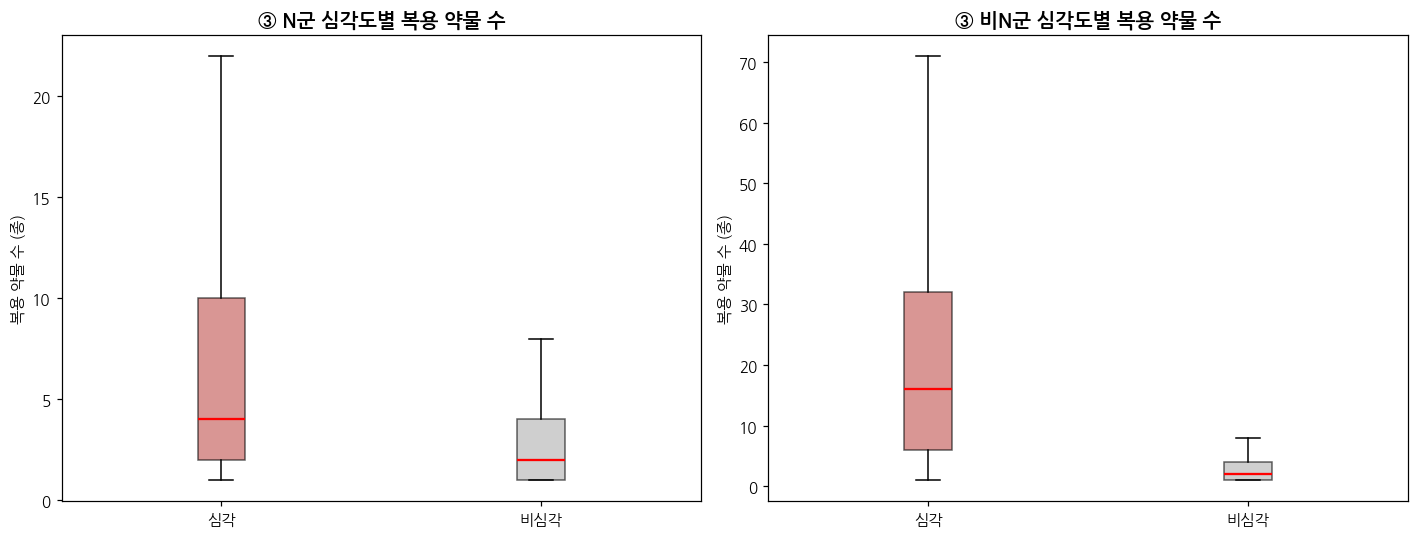

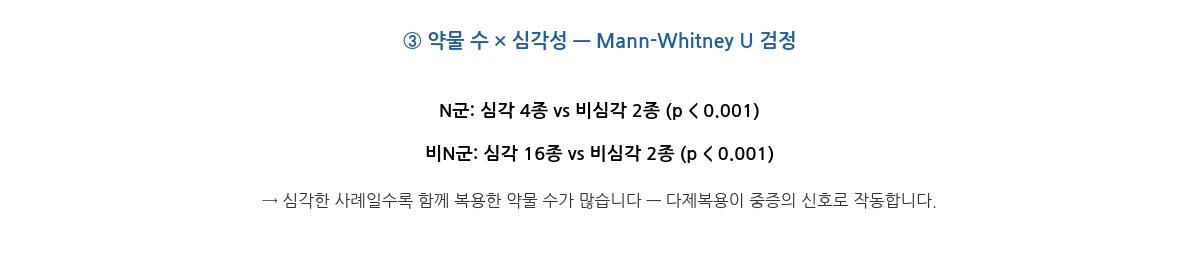

In [26]:

# ---------------------------------------------------------------------
# [CELL 3] 약물 수 × 심각성 (N군 vs 비N군)
# ---------------------------------------------------------------------
# CoT: 심각(serious) 사례와 비심각 사례의 복용 약물 수(num_drugs)를 비교.
#   연속·우편향 → Mann-Whitney U. N군과 비N군 각각 수행 → 나란히 표시.
def mwu(d):
    a = d.loc[d['serious_bin']==1, 'num_drugs']; b = d.loc[d['serious_bin']==0, 'num_drugs']
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    return a.median(), b.median(), u, p
mN, mN0, uN, pN = mwu(N)
mNN, mNN0, uNN, pNN = mwu(NN)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for i, (name, sev, non, med_s, med_n) in enumerate(
        [('N군', N, N, mN, mN0), ('비N군', NN, NN, mNN, mNN0)]):
    d = [sev.loc[sev['serious_bin']==1, 'num_drugs'],
         sev.loc[sev['serious_bin']==0, 'num_drugs']]
    bp = ax[i].boxplot(d, tick_labels=['심각','비심각'], showfliers=False, patch_artist=True,
                       medianprops=dict(color='red', lw=1.5))
    for patch, c in zip(bp['boxes'], [RED, '#b0b0b0']): patch.set_facecolor(c); patch.set_alpha(.6)
    ax[i].set_title(f'③ {name} 심각도별 복용 약물 수', fontweight='bold', fontsize=13)
    ax[i].set_ylabel('복용 약물 수 (종)')
plt.tight_layout(); plt.show()

stat_card("③ 약물 수 × 심각성 — Mann-Whitney U 검정",
    [f"N군: 심각 {mN:.0f}종 vs 비심각 {mN0:.0f}종 ({fmt_p(pN)})",
     f"비N군: 심각 {mNN:.0f}종 vs 비심각 {mNN0:.0f}종 ({fmt_p(pNN)})"],
    "심각한 사례일수록 함께 복용한 약물 수가 많습니다 — 다제복용이 중증의 신호로 작동합니다.")




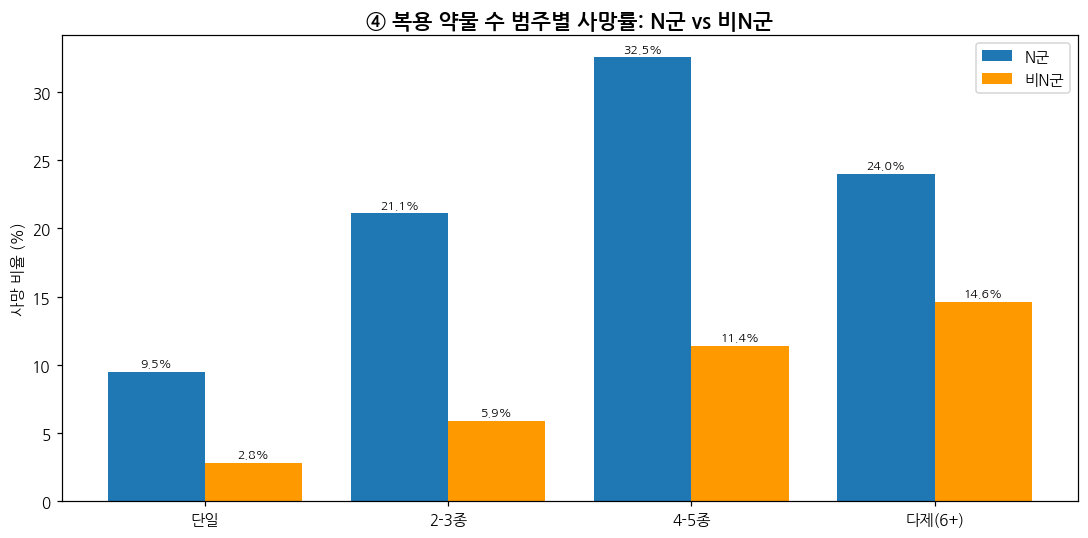

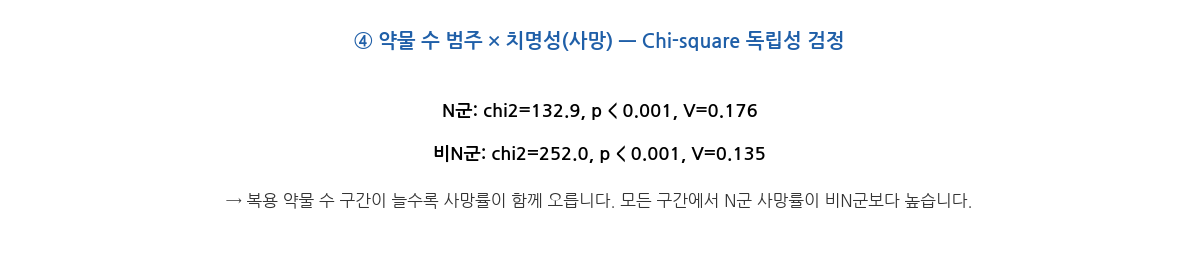

In [27]:
# ---------------------------------------------------------------------
# [CELL 4] 약물 수 범주 × 치명성(사망) (N군 vs 비N군)
# ---------------------------------------------------------------------
# CoT: 복용 약물 수 구간이 늘수록 사망률이 오르는가? 구간 × 사망 카이제곱.
#   N군/비N군 각각 검정하고, 구간별 사망률을 나란히 비교.
def cat_fatal(d):
    dd = d[d['drug_count_category'].isin(cat_order)]
    rate = dd.groupby('drug_count_category')['fatal'].mean().reindex(cat_order)
    ct = pd.crosstab(dd['drug_count_category'], dd['fatal'])[[0,1]]
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.sum().sum()*(min(ct.shape)-1)))
    return rate, chi2, p, dof, v
rate_N, chi2N4, pN4, dofN4, vN4 = cat_fatal(N)
rate_NN, chi2NN4, pNN4, dofNN4, vNN4 = cat_fatal(NN)

x = np.arange(len(cat_order)); w = 0.4
plt.figure(figsize=(10, 5))
plt.bar(x-w/2, rate_N.values*100,  w, color=BLUE,   label='N군')
plt.bar(x+w/2, rate_NN.values*100, w, color=ORANGE, label='비N군')
for i in range(len(cat_order)):
    plt.text(i-w/2, rate_N.values[i]*100+0.4,  f'{rate_N.values[i]*100:.1f}%',  ha='center', fontsize=8)
    plt.text(i+w/2, rate_NN.values[i]*100+0.4, f'{rate_NN.values[i]*100:.1f}%', ha='center', fontsize=8)
plt.xticks(x, cat_kr); plt.ylabel('사망 비율 (%)')
plt.title('④ 복용 약물 수 범주별 사망률: N군 vs 비N군', fontweight='bold', fontsize=14)
plt.legend(); plt.tight_layout(); plt.show()

stat_card("④ 약물 수 범주 × 치명성(사망) — Chi-square 독립성 검정",
    [f"N군: chi2={chi2N4:.1f}, {fmt_p(pN4)}, V={vN4:.3f}",
     f"비N군: chi2={chi2NN4:.1f}, {fmt_p(pNN4)}, V={vNN4:.3f}"],
    "복용 약물 수 구간이 늘수록 사망률이 함께 오릅니다. 모든 구간에서 N군 사망률이 비N군보다 높습니다.")



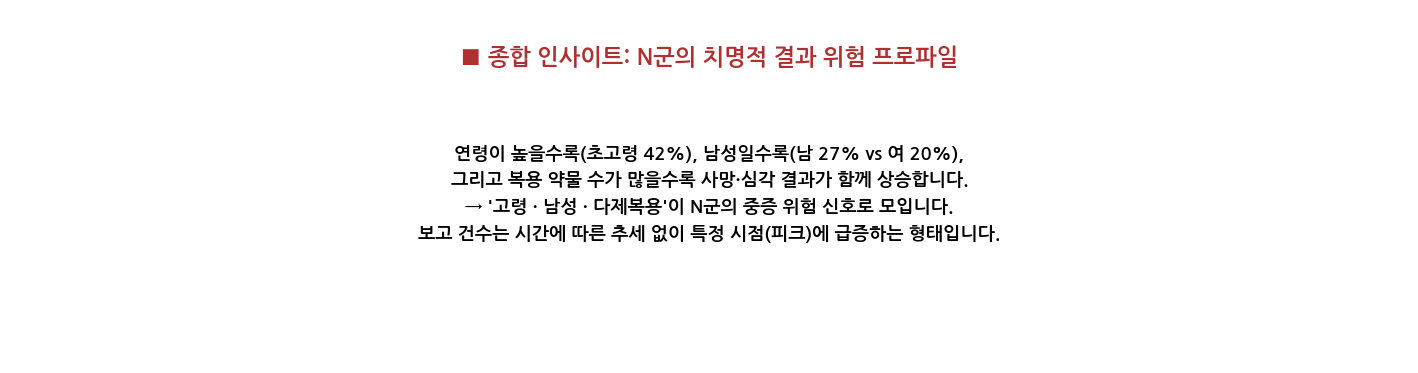

 ATC-N군 심화 분석 검정 요약
① 연령×사망 chi2=175.5 p < 0.001 | 최고 초고령
② 성별×사망 남 27.4% 여 19.9% chi2=28.9 p < 0.001
③ 약물수×심각 N(p < 0.001) 비N(p < 0.001)
④ 약물범주×사망 N chi2=132.9 비N chi2=252.0
⑤ 추세 rho=-0.027 p = 0.937 피크 2020Q3


In [28]:
# ---------------------------------------------------------------------
# [CELL 6] 종합 인사이트 (전체를 관통하는 한 줄 결론)
# ---------------------------------------------------------------------
# CoT: 개별 검정은 위에서 그래프 옆에 이미 붙였으니, 여기선 5개를 엮은
#      통합 메시지만 한 장으로 제시한다.
top_age = age_kr[fatal_rate['rate'].idxmax()]
fig, ax = plt.subplots(figsize=(13, 3.5)); ax.axis('off')
ax.text(0.5, 0.9, "■ 종합 인사이트: N군의 치명적 결과 위험 프로파일", ha='center', va='top',
        fontsize=15, fontweight='bold', color='#b03030', transform=ax.transAxes)
summary = (
    f"연령이 높을수록(초고령 {fatal_rate['rate'].max()*100:.0f}%), 남성일수록"
    f"(남 {fr.loc['Male','rate']*100:.0f}% vs 여 {fr.loc['Female','rate']*100:.0f}%),\n"
    "그리고 복용 약물 수가 많을수록 사망·심각 결과가 함께 상승합니다.\n"
    "→ '고령 · 남성 · 다제복용'이 N군의 중증 위험 신호로 모입니다.\n"
    "보고 건수는 시간에 따른 추세 없이 특정 시점(피크)에 급증하는 형태입니다."
)
ax.text(0.5, 0.62, summary, ha='center', va='top', fontsize=12,
        fontweight='bold', linespacing=1.7, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*62)
print(" ATC-N군 심화 분석 검정 요약")
print("="*62)
print(f"① 연령×사망 chi2={chi2_af:.1f} {fmt_p(p_af)} | 최고 {top_age}")
print(f"② 성별×사망 남 {fr.loc['Male','rate']*100:.1f}% 여 {fr.loc['Female','rate']*100:.1f}% chi2={chi2_sf:.1f} {fmt_p(p_sf)}")
print(f"③ 약물수×심각 N({fmt_p(pN)}) 비N({fmt_p(pNN)})")
print(f"④ 약물범주×사망 N chi2={chi2N4:.1f} 비N chi2={chi2NN4:.1f}")
print(f"⑤ 추세 rho={rho:.3f} {fmt_p(p_tr)} 피크 {peak}")
print("="*62)

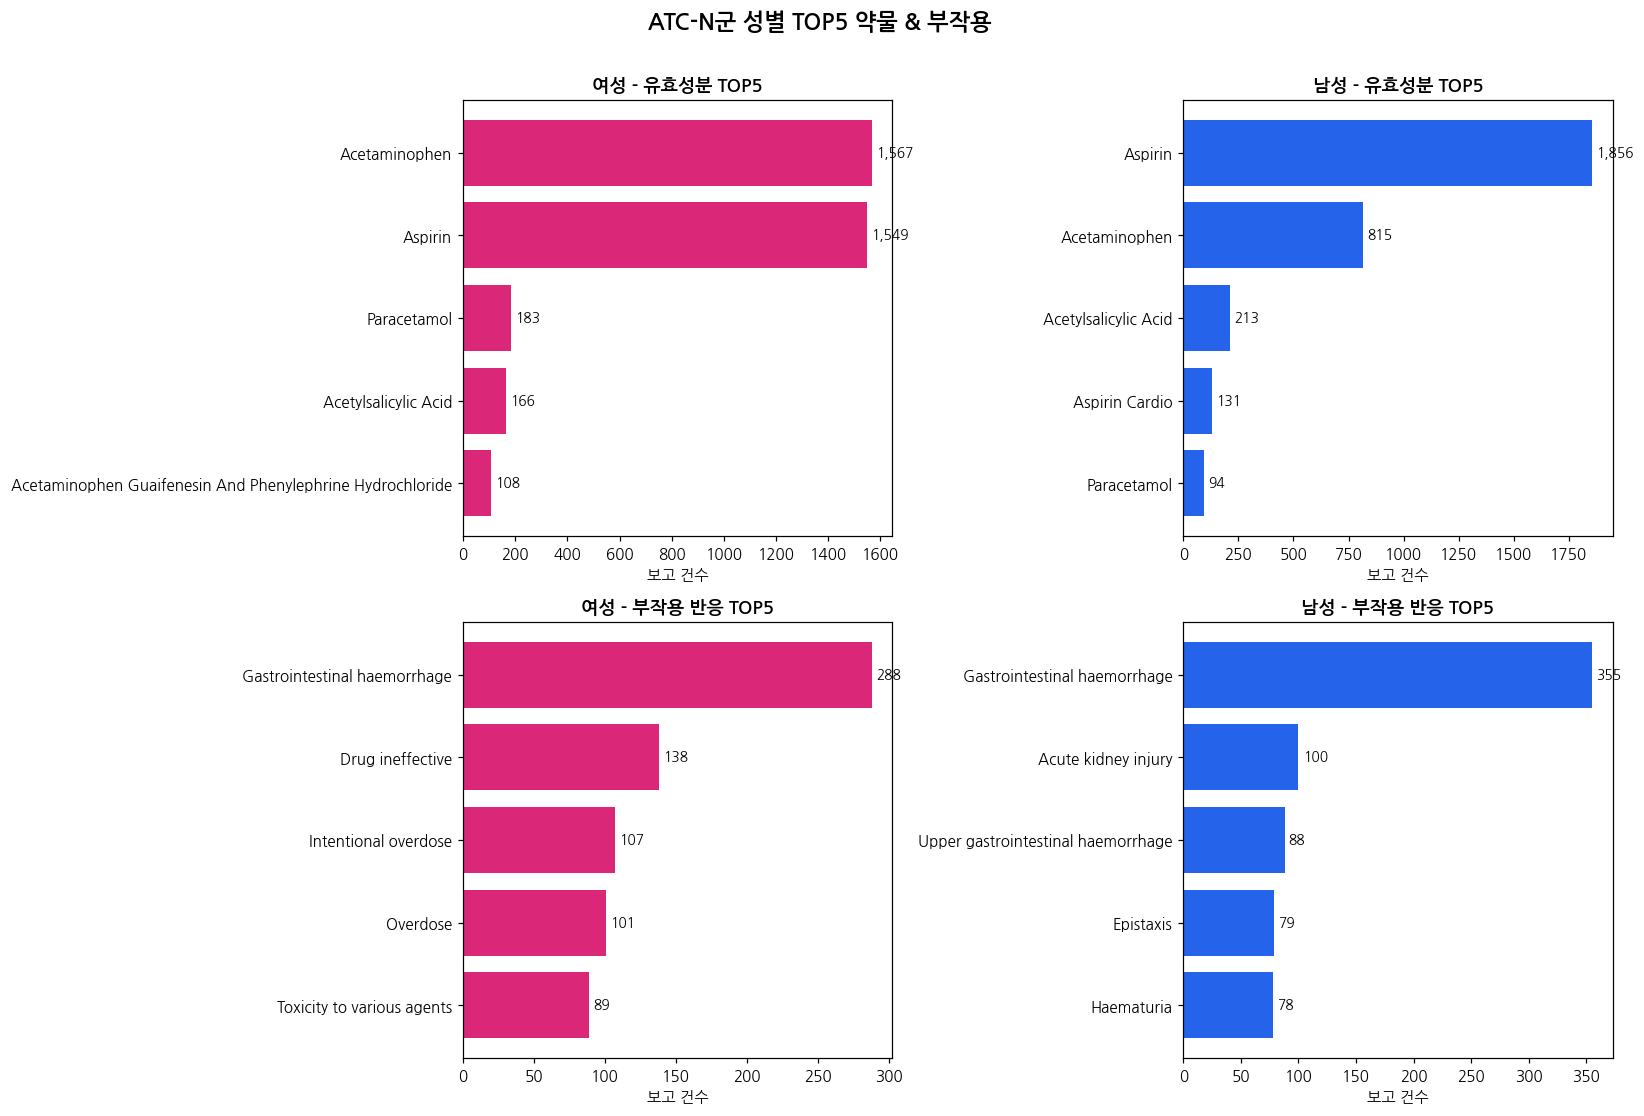

In [29]:
"""## **성별 TOP5 약물 & 그에 따른 TOP5 부작용**"""


# --- 이 셀 단독 실행도 되도록 필요한 변수 재정의 (파일 스타일과 동일) ---
df['is_N'] = (df['WHO_ATC'] == 'N')
N = df[df['is_N']].copy()
FEMALE_C, MALE_C = '#db2777', '#2563eb'   # 여성/남성 색
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


# ---------------------------------------------------------------------
# 정제 유틸 (Self-Refine 1단계)
# ---------------------------------------------------------------------
# CoT: 유효성분(suspect_drug)·반응(reactions)은 '; ' 다중값 → explode.
#   유효성분은 용량·제형 표기가 섞여 같은 성분이 쪼개지므로 성분 단위로 병합.
#   (동의어 ASPIRIN=ACETYLSALICYLIC ACID 까지는 병합 안 함 → 해석 시 참고)
def explode_clean(series):
    s = series.dropna().astype(str).str.split(';').explode().str.strip()
    return s[~s.str.lower().isin(['unknown', ''])]

def norm_ingredient(s):
    s = s.upper()
    s = re.sub(r'\d+\.?\d*\s*(MG|MCG|ML|G|%|IU)', '', s)
    s = re.sub(r'\b(TABLET|TABLETS|EXTENDED|RELEASE|CAPSULE|CAPSULES|ORAL|'
               r'SOLUTION|PAIN|RELIEVER|EXTRA|MAXIMUM|STRENGTH|CHEWABLE|COATED|'
               r'DELAYED|NON-ASPIRIN|INFANTS|CHILDRENS|ADULT|LOW|DOSE)\b', '', s)
    s = re.sub(r'[^A-Z ]', '', s)
    return re.sub(r'\s+', ' ', s).strip()

def top5_ingredient(sub):
    ing = explode_clean(sub['suspect_drug']).map(norm_ingredient)
    ing = ing[ing != '']
    return ing.value_counts().head(5)

def top5_reaction(sub):
    return explode_clean(sub['reactions']).value_counts().head(5)

F = N[N['patient_sex'] == 'Female']
M = N[N['patient_sex'] == 'Male']
f_drug, m_drug = top5_ingredient(F), top5_ingredient(M)
f_rx,   m_rx   = top5_reaction(F),   top5_reaction(M)


# ---------------------------------------------------------------------
# 그래프: 2x2 (위=약물 TOP5, 아래=부작용 TOP5 / 좌=여성, 우=남성)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

def draw(ax, s, title, color):
    labels = [x.title() if x.isupper() else x for x in s.index]
    bars = ax.barh(labels[::-1], s.values[::-1], color=color)
    for b, v in zip(bars, s.values[::-1]):
        ax.text(v + max(s.values)*0.01, b.get_y()+b.get_height()/2, f'{v:,}',
                va='center', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('보고 건수')

draw(axes[0,0], f_drug, '여성 - 유효성분 TOP5', FEMALE_C)
draw(axes[0,1], m_drug, '남성 - 유효성분 TOP5', MALE_C)
draw(axes[1,0], f_rx,   '여성 - 부작용 반응 TOP5', FEMALE_C)
draw(axes[1,1], m_rx,   '남성 - 부작용 반응 TOP5', MALE_C)
plt.suptitle('ATC-N군 성별 TOP5 약물 & 부작용', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()



[성별 × 위장관 출혈] 여성 29.6% vs 남성 42.2% | chi2=65.3, p < 0.001, Cramer's V=0.131
  약물 TOP5 겹침: 4/5  |  부작용 TOP5 겹침: 1/5
  남성 특유 부작용: ['Acute kidney injury', 'Epistaxis', 'Haematuria', 'Upper gastrointestinal haemorrhage']
  여성 특유 부작용: ['Drug ineffective', 'Intentional overdose', 'Overdose', 'Toxicity to various agents']


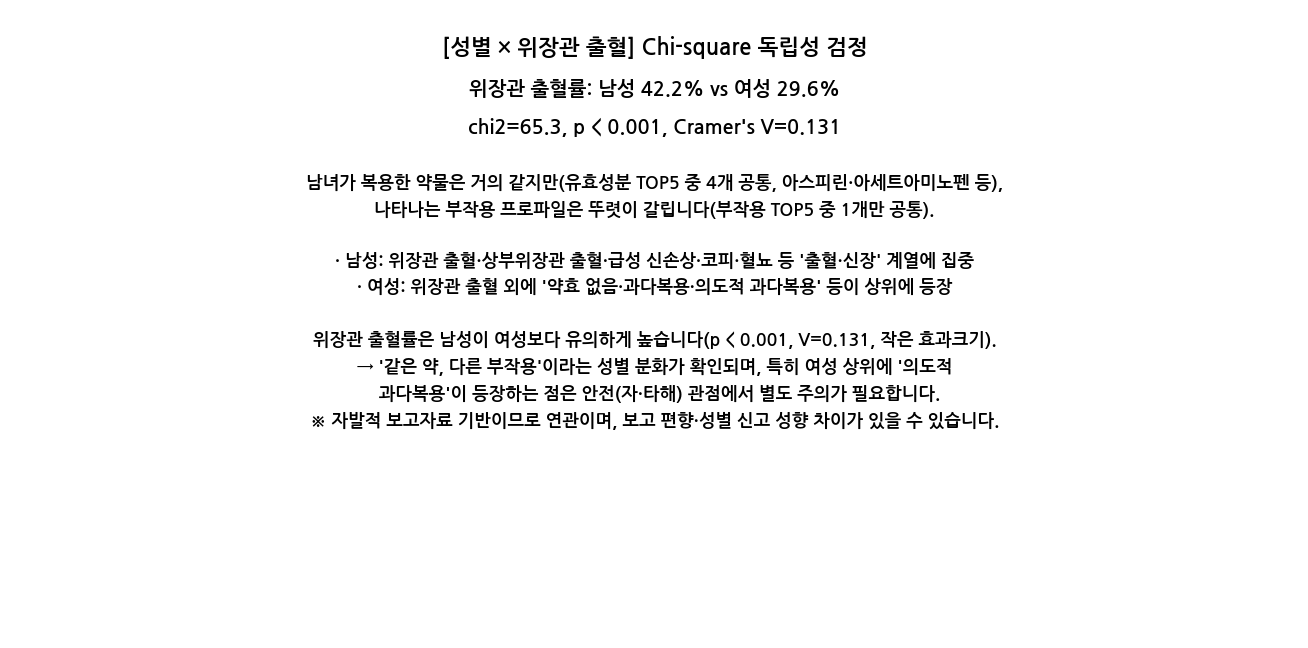

 ATC-N군 성별 약물·부작용 검정 요약
성별×위장관출혈 남 42.2% vs 여 29.6% | chi2=65.3 p < 0.001 V=0.131
약물 TOP5 겹침 4/5  |  부작용 TOP5 겹침 1/5


In [30]:

# ---------------------------------------------------------------------
# 통계검정: 성별 × 위장관 출혈  (Chi-square 독립성 + Cramer's V)
# ---------------------------------------------------------------------
# CoT: 남녀가 먹는 약(성분)은 거의 같은데 부작용 프로파일이 다른지 본다.
#   대표 부작용인 '위장관 출혈' 발생률에 성별 차이가 있는지 2x2 카이제곱.
#   (출혈=반응에 haemorrhage/hemorrhage/bleed 포함)
N['gi_bleed'] = N['reactions'].fillna('').str.contains('haemorrhage|hemorrhage|bleed', case=False)
s = N[N['patient_sex'].isin(['Male', 'Female'])]
ct = pd.crosstab(s['patient_sex'], s['gi_bleed'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))
gi_f = s.loc[s['patient_sex']=='Female', 'gi_bleed'].mean()*100
gi_m = s.loc[s['patient_sex']=='Male',   'gi_bleed'].mean()*100

# 겹침 분석 (약물 vs 부작용의 성별 공통도)
drug_overlap = len(set(f_drug.index) & set(m_drug.index))
rx_overlap   = len(set(f_rx.index)   & set(m_rx.index))

print(f"[성별 × 위장관 출혈] 여성 {gi_f:.1f}% vs 남성 {gi_m:.1f}% | "
      f"chi2={chi2:.1f}, {fmt_p(p)}, Cramer's V={v:.3f}")
print(f"  약물 TOP5 겹침: {drug_overlap}/5  |  부작용 TOP5 겹침: {rx_overlap}/5")
print(f"  남성 특유 부작용: {sorted(set(m_rx.index)-set(f_rx.index))}")
print(f"  여성 특유 부작용: {sorted(set(f_rx.index)-set(m_rx.index))}")


# ---------------------------------------------------------------------
# 통계검정 인사이트 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14.5,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.07-i*0.06, ln, ha='center', va='top',
                fontsize=13, fontweight='bold', transform=ax.transAxes)

block(0.96, "[성별 × 위장관 출혈] Chi-square 독립성 검정", [
    f"위장관 출혈률: 남성 {gi_m:.1f}% vs 여성 {gi_f:.1f}%",
    f"chi2={chi2:.1f}, {fmt_p(p)}, Cramer's V={v:.3f}"])

v_txt = "작은 효과크기" if v < 0.3 else "중간 이상 효과크기"
interp = (
    f"남녀가 복용한 약물은 거의 같지만(유효성분 TOP5 중 {drug_overlap}개 공통, 아스피린·아세트아미노펜 등),\n"
    f"나타나는 부작용 프로파일은 뚜렷이 갈립니다(부작용 TOP5 중 {rx_overlap}개만 공통).\n\n"
    "· 남성: 위장관 출혈·상부위장관 출혈·급성 신손상·코피·혈뇨 등 '출혈·신장' 계열에 집중\n"
    "· 여성: 위장관 출혈 외에 '약효 없음·과다복용·의도적 과다복용' 등이 상위에 등장\n\n"
    f"위장관 출혈률은 남성이 여성보다 유의하게 높습니다({fmt_p(p)}, V={v:.3f}, {v_txt}).\n"
    "→ '같은 약, 다른 부작용'이라는 성별 분화가 확인되며, 특히 여성 상위에 '의도적\n"
    "  과다복용'이 등장하는 점은 안전(자·타해) 관점에서 별도 주의가 필요합니다.\n"
    "※ 자발적 보고자료 기반이므로 연관이며, 보고 편향·성별 신고 성향 차이가 있을 수 있습니다."
)
ax.text(0.5, 0.74, interp, ha='center', va='top', fontsize=11.5,
        fontweight='bold', linespacing=1.65, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*60)
print(" ATC-N군 성별 약물·부작용 검정 요약")
print("="*60)
print(f"성별×위장관출혈 남 {gi_m:.1f}% vs 여 {gi_f:.1f}% | chi2={chi2:.1f} {fmt_p(p)} V={v:.3f}")
print(f"약물 TOP5 겹침 {drug_overlap}/5  |  부작용 TOP5 겹침 {rx_overlap}/5")
print("="*60)

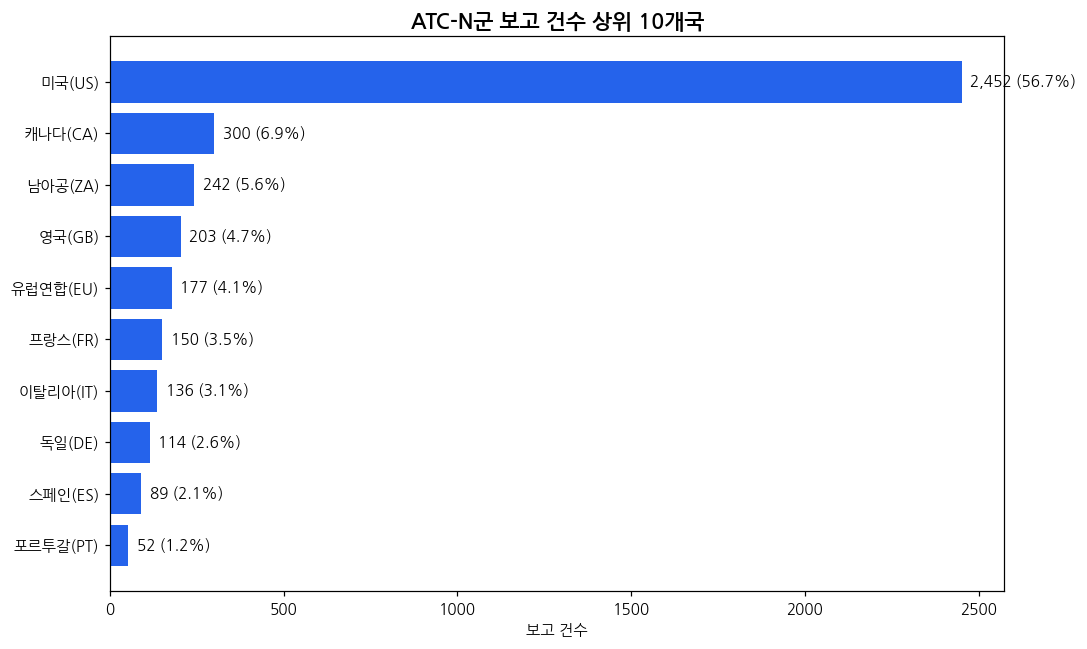

[국가별 TOP10 적합도] chi2=12171.9, p < 0.001 → 균등분포 아님(특정국 편중)
  1위 미국(US): 전체의 56.7%
  TOP10이 전체 N군의 90.5% 차지 (고유 국가 53개국)


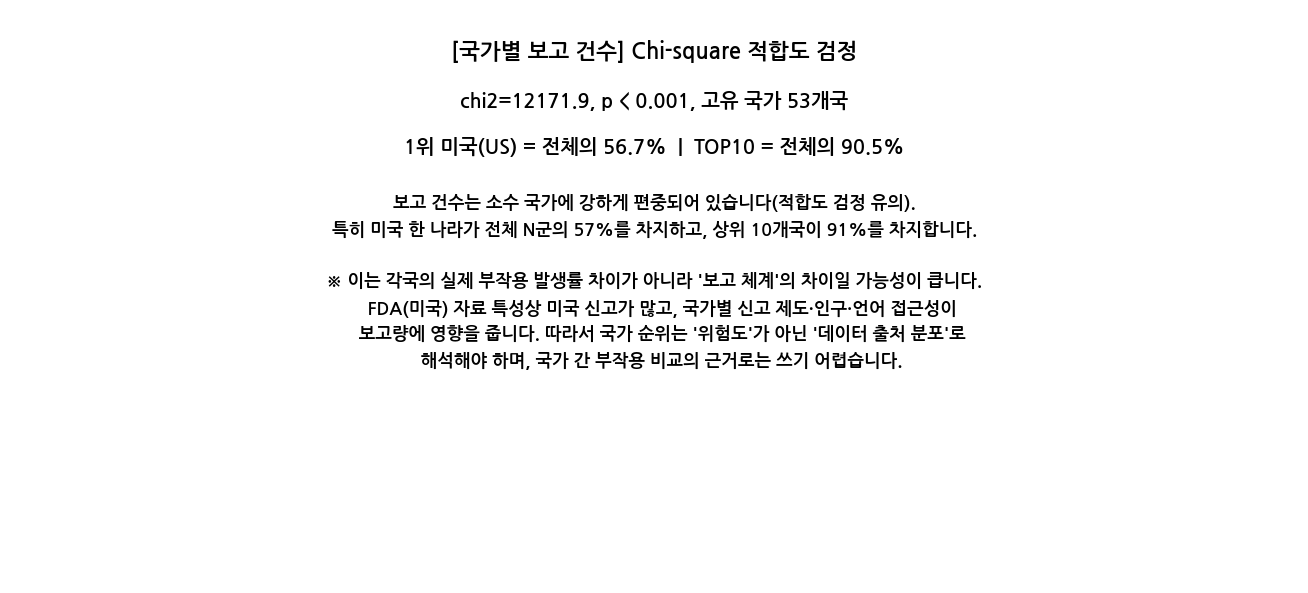

 ATC-N군 국가별 보고 검정 요약
적합도 chi2=12171.9 p < 0.001 | 미국 56.7% | TOP10 90.5%


In [31]:
"""## **N군 보고 건수 상위 10개국**"""

# =====================================================================
#  [추가 분석] ATC-N군 국가별 보고 건수 TOP10
#   - 상위 10개국 보고 건수 막대
#   - 통계검정: 카이제곱 적합도 (국가별 건수가 균등한가 = 특정국 편중?)
#   - 통계검정 인사이트 카드
#
#  방법론: CoT(검정 선택 근거 주석) + Self-Refine(정제→계산→검증)
#  건수 기준.
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

# 한글 폰트 (앞 셀에서 이미 적용됐다면 그대로 유지됨)
try: matplotlib.rc('font', family='NanumGothic')
except Exception: pass
matplotlib.rcParams['axes.unicode_minus'] = False

# --- 이 셀 단독 실행도 되도록 필요한 변수 재정의 (파일 스타일과 동일) ---
df['is_N'] = (df['WHO_ATC'] == 'N')
N = df[df['is_N']].copy()
BLUE = '#2563eb'
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


# ---------------------------------------------------------------------
# 국가별 TOP10  (Self-Refine: Unknown 제외, 국가코드 → 한글명)
# ---------------------------------------------------------------------
# CoT: country 컬럼은 국가코드(US, CA...). 'Unknown'은 실질 결측이라 제외.
#   건수 상위 10개국을 집계하고, 읽기 쉬운 한글명으로 라벨링.
country_kr = {'US':'미국','CA':'캐나다','ZA':'남아공','GB':'영국','EU':'유럽연합',
              'FR':'프랑스','IT':'이탈리아','DE':'독일','ES':'스페인','PT':'포르투갈',
              'JP':'일본','AU':'호주','NL':'네덜란드','BR':'브라질','CN':'중국'}
vc = N[N['country'] != 'Unknown']['country'].value_counts()
top10 = vc.head(10)
labels = [f"{country_kr.get(c, c)}({c})" for c in top10.index]

# --- 그래프 ---
plt.figure(figsize=(10, 6))
bars = plt.barh(labels[::-1], top10.values[::-1], color=BLUE)
for b, v in zip(bars, top10.values[::-1]):
    plt.text(v + max(top10.values)*0.01, b.get_y()+b.get_height()/2,
             f'{v:,} ({v/len(N)*100:.1f}%)', va='center', fontsize=10)
plt.title('ATC-N군 보고 건수 상위 10개국', fontweight='bold', fontsize=14)
plt.xlabel('보고 건수'); plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
# 통계검정: 카이제곱 적합도 (국가별 건수가 균등한가)
# ---------------------------------------------------------------------
# CoT: 귀무가설 = TOP10 국가의 보고 건수가 균등 분포.
#   기각되면 특정 국가(예: 미국)에 강하게 편중되었다는 뜻.
chi2, p = stats.chisquare(top10.values)
us_share = top10.iloc[0] / len(N) * 100
top10_share = top10.sum() / len(N) * 100

print(f"[국가별 TOP10 적합도] chi2={chi2:.1f}, {fmt_p(p)} → 균등분포 아님(특정국 편중)")
print(f"  1위 {labels[0]}: 전체의 {us_share:.1f}%")
print(f"  TOP10이 전체 N군의 {top10_share:.1f}% 차지 (고유 국가 {vc.shape[0]}개국)")


# ---------------------------------------------------------------------
# 통계검정 인사이트 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5.5)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14.5,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.09-i*0.08, ln, ha='center', va='top',
                fontsize=13, fontweight='bold', transform=ax.transAxes)

block(0.95, "[국가별 보고 건수] Chi-square 적합도 검정", [
    f"chi2={chi2:.1f}, {fmt_p(p)}, 고유 국가 {vc.shape[0]}개국",
    f"1위 {labels[0]} = 전체의 {us_share:.1f}%  |  TOP10 = 전체의 {top10_share:.1f}%"])

interp = (
    f"보고 건수는 소수 국가에 강하게 편중되어 있습니다(적합도 검정 유의).\n"
    f"특히 미국 한 나라가 전체 N군의 {us_share:.0f}%를 차지하고, 상위 10개국이 "
    f"{top10_share:.0f}%를 차지합니다.\n\n"
    "※ 이는 각국의 실제 부작용 발생률 차이가 아니라 '보고 체계'의 차이일 가능성이 큽니다.\n"
    "   FDA(미국) 자료 특성상 미국 신고가 많고, 국가별 신고 제도·인구·언어 접근성이\n"
    "   보고량에 영향을 줍니다. 따라서 국가 순위는 '위험도'가 아닌 '데이터 출처 분포'로\n"
    "   해석해야 하며, 국가 간 부작용 비교의 근거로는 쓰기 어렵습니다."
)
ax.text(0.5, 0.68, interp, ha='center', va='top', fontsize=11.5,
        fontweight='bold', linespacing=1.65, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*58)
print(" ATC-N군 국가별 보고 검정 요약")
print("="*58)
print(f"적합도 chi2={chi2:.1f} {fmt_p(p)} | 미국 {us_share:.1f}% | TOP10 {top10_share:.1f}%")
print("="*58)

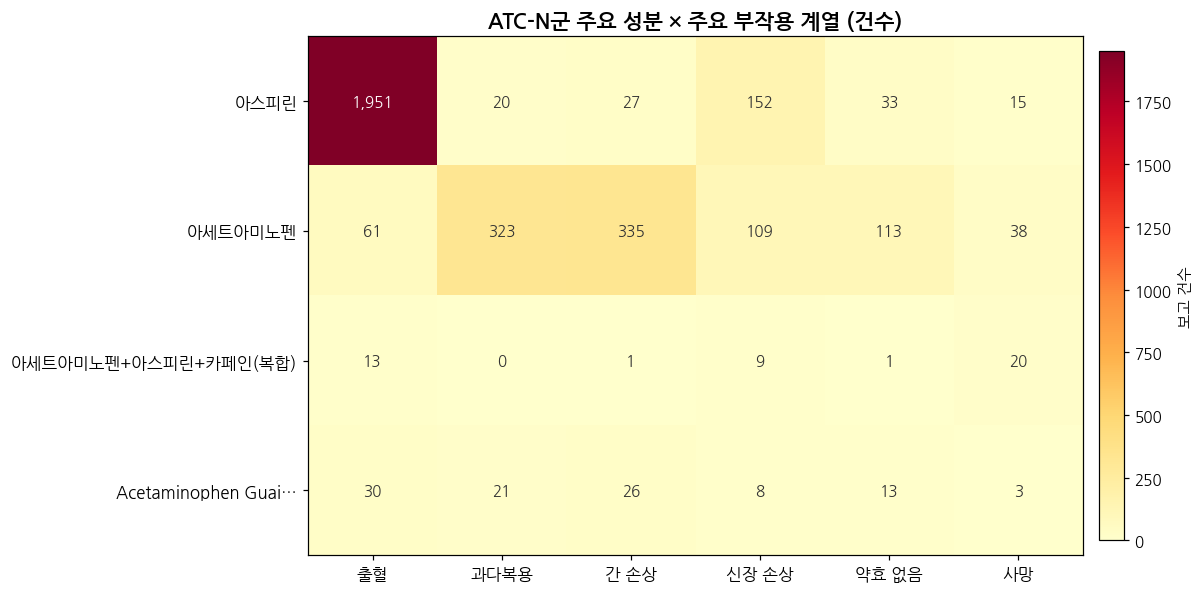

[성분 × 부작용 독립성] chi2=2644.1, dof=15, p < 0.001, Cramer's V=0.515
  아스피린: 최다 부작용 = 출혈 (1,951건)
  아세트아미노펜: 최다 부작용 = 간 손상 (335건)
  아세트아미노펜+아스피린+카페인(복합): 최다 부작용 = 사망 (20건)
  Acetaminophen Guai…: 최다 부작용 = 출혈 (30건)


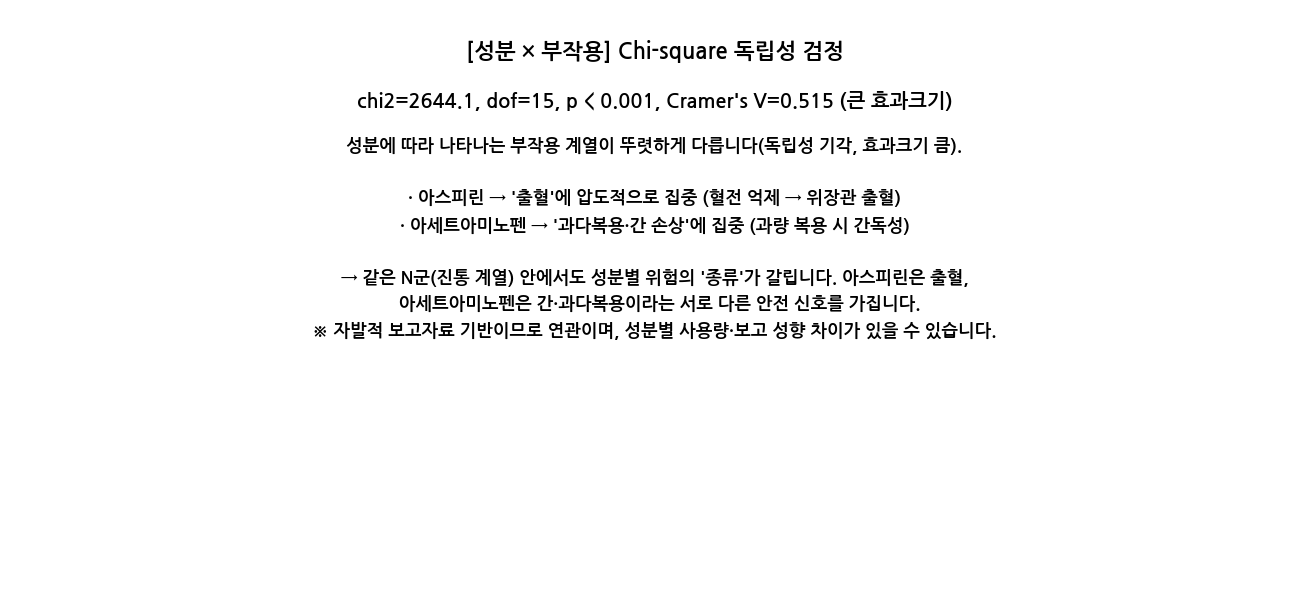

 ATC-N군 성분별 부작용 검정 요약
성분×부작용 chi2=2644.1 p < 0.001 V=0.515
  아스피린 → 출혈
  아세트아미노펜 → 간 손상
  아세트아미노펜+아스피린+카페인(복합) → 사망
  Acetaminophen Guai… → 출혈


In [32]:


df['is_N'] = (df['WHO_ATC'] == 'N')
N = df[df['is_N']].copy()
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


# ---------------------------------------------------------------------
# Self-Refine 1: 성분 정규화 + 동의어 병합
# ---------------------------------------------------------------------
# CoT: suspect_drug는 용량·제형이 섞여 성분이 쪼개진다. 정규화 후,
#   같은 약의 다른 이름(아세틸살리실산=아스피린, 파라세타몰=아세트아미노펜)을 병합.
#   각 보고서의 '대표 성분'은 첫 번째 성분으로 잡는다.
def norm_ing(x):
    x = x.upper()
    x = re.sub(r'\d+\.?\d*\s*(MG|MCG|ML|G|%|IU)', '', x)
    x = re.sub(r'\b(CARDIO|TABLET|TABLETS|EXTENDED|RELEASE|CAPSULE|CAPSULES|ORAL|'
               r'SOLUTION|EC|BUFFERED|ENTERIC|COATED|LOW|DOSE)\b', '', x)
    x = re.sub(r'[^A-Z ]', '', x)
    return re.sub(r'\s+', ' ', x).strip()

SYN = {'ACETYLSALICYLIC ACID': 'ASPIRIN', 'PARACETAMOL': 'ACETAMINOPHEN'}
def first_ingredient(s):
    if pd.isna(s): return None
    parts = [SYN.get(norm_ing(p), norm_ing(p)) for p in str(s).split(';')
             if norm_ing(p) and 'UNKNOWN' not in norm_ing(p)]
    return parts[0] if parts else None

N['ing'] = N['suspect_drug'].map(first_ingredient)
top_ings = N['ing'].value_counts().head(4).index.tolist()

# 라벨 간결화 (복합제는 축약)
ing_label = {
    'ASPIRIN': '아스피린',
    'ACETAMINOPHEN': '아세트아미노펜',
    'ACETAMINOPHENASPIRINCAFFEINE': '아세트아미노펜+아스피린+카페인(복합)',
}
def label_of(i): return ing_label.get(i, i.title()[:18]+'…' if len(i) > 18 else i.title())


# ---------------------------------------------------------------------
# Self-Refine 2: 부작용을 임상 계열로 그룹화
# ---------------------------------------------------------------------
# CoT: 개별 반응은 3,000종 넘어 히트맵이 불가. 임상적으로 의미있는 계열로 묶는다.
def rx_group(r):
    r = r.lower()
    if any(k in r for k in ['haemorrh', 'hemorrh', 'bleed', 'epistaxis', 'haematuria']): return '출혈'
    if 'overdose' in r: return '과다복용'
    if 'hepatic' in r or 'liver' in r: return '간 손상'
    if 'renal' in r or 'kidney' in r: return '신장 손상'
    if 'ineffective' in r: return '약효 없음'
    if 'death' in r: return '사망'
    return None  # 기타는 히트맵에서 제외

rx_cats = ['출혈', '과다복용', '간 손상', '신장 손상', '약효 없음', '사망']
rows = {}
for ing in top_ings:
    sub = N[N['ing'] == ing]
    rx = sub['reactions'].dropna().astype(str).str.split(';').explode().str.strip()
    rx = rx[~rx.str.lower().isin(['unknown', ''])]
    g = rx.map(rx_group).dropna()
    rows[label_of(ing)] = g.value_counts()
mat = pd.DataFrame(rows).T.reindex(columns=rx_cats).fillna(0).astype(int)


# ---------------------------------------------------------------------
# 히트맵 (성분 × 부작용 계열, 건수)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(mat.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(rx_cats))); ax.set_xticklabels(rx_cats, fontsize=11)
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index, fontsize=11)
# 셀 안에 건수 표기
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f'{v:,}', ha='center', va='center', fontsize=10,
                color='white' if v > mat.values.max()*0.5 else '#333')
ax.set_title('ATC-N군 주요 성분 × 주요 부작용 계열 (건수)', fontweight='bold', fontsize=14)
plt.colorbar(im, ax=ax, label='보고 건수', fraction=0.03, pad=0.02)
plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
# 통계검정: 카이제곱 독립성 (성분 × 부작용계열)
# ---------------------------------------------------------------------
# CoT: 귀무가설 = 성분과 부작용 계열이 독립(성분 무관하게 부작용 분포 동일).
#   기각되면 '성분마다 잘 일으키는 부작용이 다르다'는 뜻. + 효과크기 Cramer's V.
chi2, p, dof, _ = stats.chi2_contingency(mat.values)
v = np.sqrt(chi2 / (mat.values.sum() * (min(mat.shape)-1)))
# 성분별 최다 부작용
top_rx_by_ing = {idx: mat.loc[idx].idxmax() for idx in mat.index}

print(f"[성분 × 부작용 독립성] chi2={chi2:.1f}, dof={dof}, {fmt_p(p)}, Cramer's V={v:.3f}")
for k, val in top_rx_by_ing.items():
    print(f"  {k}: 최다 부작용 = {val} ({mat.loc[k].max():,}건)")


# ---------------------------------------------------------------------
# 통계검정 인사이트 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5.5)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14.5,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.09-i*0.08, ln, ha='center', va='top',
                fontsize=13, fontweight='bold', transform=ax.transAxes)

block(0.95, "[성분 × 부작용] Chi-square 독립성 검정", [
    f"chi2={chi2:.1f}, dof={dof}, {fmt_p(p)}, Cramer's V={v:.3f} (큰 효과크기)"])

interp = (
    "성분에 따라 나타나는 부작용 계열이 뚜렷하게 다릅니다(독립성 기각, 효과크기 큼).\n\n"
    "· 아스피린 → '출혈'에 압도적으로 집중 (혈전 억제 → 위장관 출혈)\n"
    "· 아세트아미노펜 → '과다복용·간 손상'에 집중 (과량 복용 시 간독성)\n\n"
    "→ 같은 N군(진통 계열) 안에서도 성분별 위험의 '종류'가 갈립니다. 아스피린은 출혈,\n"
    "  아세트아미노펜은 간·과다복용이라는 서로 다른 안전 신호를 가집니다.\n"
    "※ 자발적 보고자료 기반이므로 연관이며, 성분별 사용량·보고 성향 차이가 있을 수 있습니다."
)
ax.text(0.5, 0.78, interp, ha='center', va='top', fontsize=11.5,
        fontweight='bold', linespacing=1.65, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*58)
print(" ATC-N군 성분별 부작용 검정 요약")
print("="*58)
print(f"성분×부작용 chi2={chi2:.1f} {fmt_p(p)} V={v:.3f}")
for k, val in top_rx_by_ing.items():
    print(f"  {k} → {val}")
print("="*58)

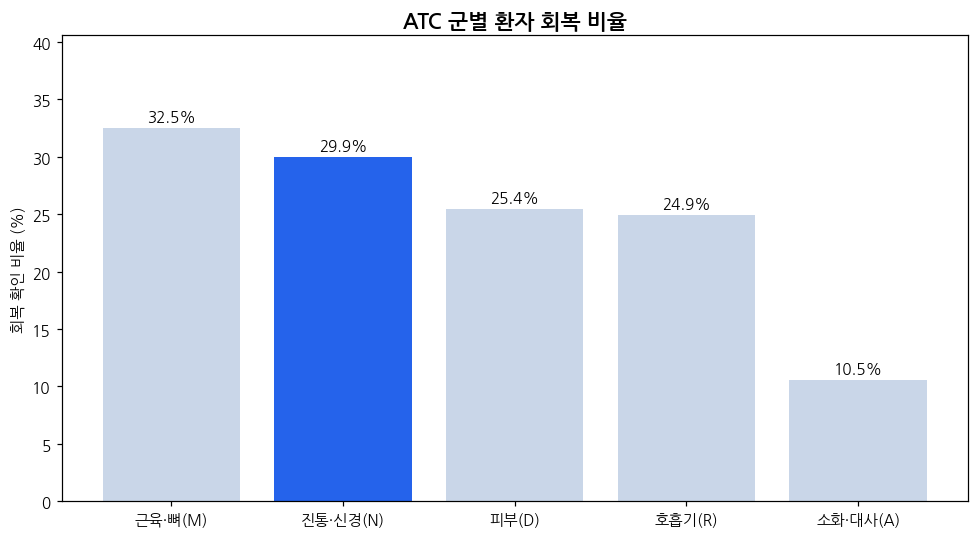

[① 군별 회복률] 5군 전체 chi2=1054.8, dof=4, p < 0.001, V=0.241
  N군 29.9% vs 비N군 16.0% | N vs 비N chi2=407.0, p < 0.001, V=0.149


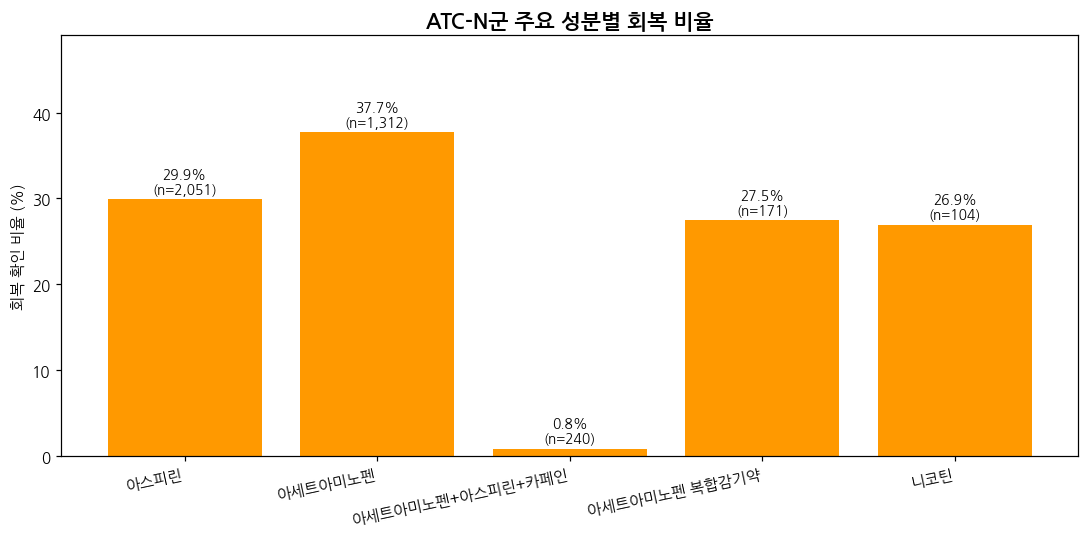

[② 성분별 회복률] chi2=133.6, dof=4, p < 0.001, V=0.186
  아스피린: 29.9% (n=2,051)
  아세트아미노펜: 37.7% (n=1,312)
  아세트아미노펜+아스피린+카페인: 0.8% (n=240)
  아세트아미노펜 복합감기약: 27.5% (n=171)
  니코틴: 26.9% (n=104)


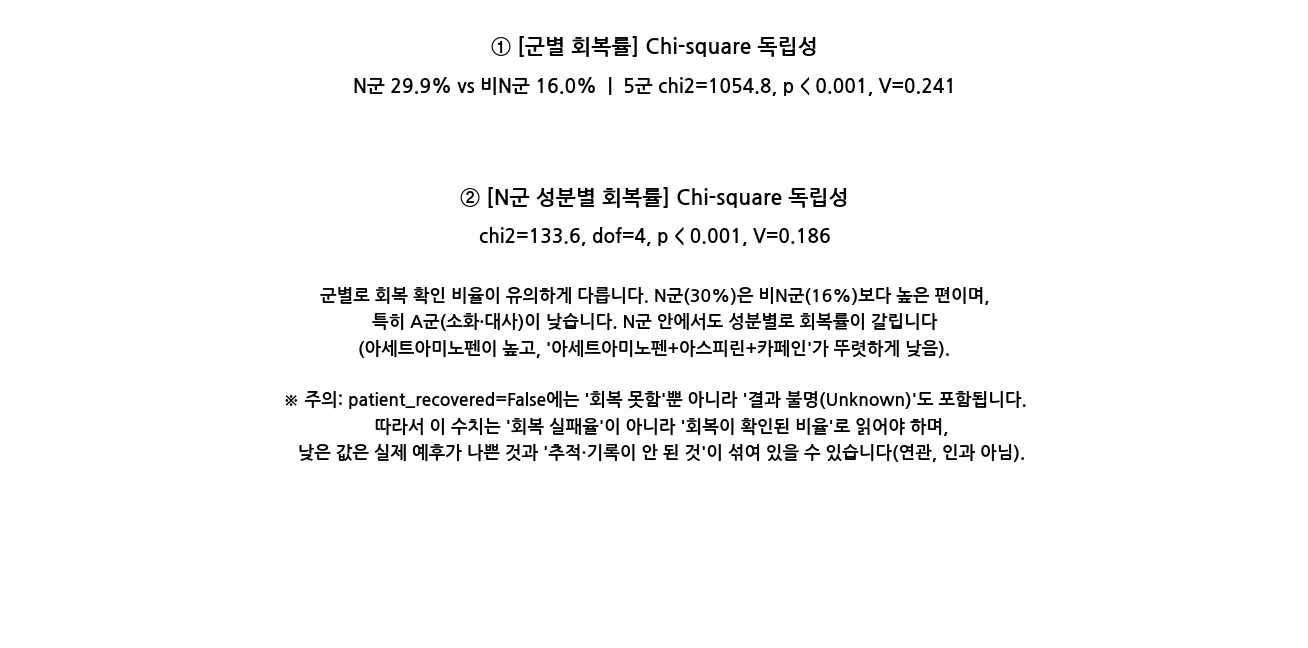

 환자 회복 비율 검정 요약
① 군별 chi2=1054.8 p < 0.001 V=0.241 | N 29.9% vs 비N 16.0%
② 성분별 chi2=133.6 p < 0.001 V=0.186


In [33]:
"""## **환자 회복 비율 — 군별 & N군 성분별**"""

# =====================================================================
#  [추가 분석] 환자 회복 비율(patient_recovered)
#   (1) N군 vs 다른 ATC군 회복률   : 카이제곱 독립성 + Cramer's V
#   (2) N군 주요 성분별 회복률      : 카이제곱 독립성 + Cramer's V
#   + 통계검정 인사이트 카드
#
#  방법론: CoT(검정 선택 근거) + Self-Refine(정제→계산→검증)
#  회복은 '비율'로 봄(그 외는 건수).
#  ※ patient_recovered=False 에는 '회복 못함'뿐 아니라 '결과 불명'도 섞여 있어,
#    여기서는 "회복(True)으로 확인된 비율"로 해석한다(아래 인사이트에 명시).
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
from scipy import stats

try: matplotlib.rc('font', family='NanumGothic')
except Exception: pass
matplotlib.rcParams['axes.unicode_minus'] = False

df['is_N'] = (df['WHO_ATC'] == 'N')
df['rec'] = df['patient_recovered'].astype(int)
BLUE, ORANGE = '#2563eb', '#ff9900'
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


# ---------------------------------------------------------------------
# (1) N군 vs 다른 ATC군 회복률
# ---------------------------------------------------------------------
# CoT: 5개 군의 회복률을 비교. 군 × 회복 카이제곱(전체) + N vs 비N 2x2.
#   막대는 회복률(%), N군만 색 강조.
group_kr = {'A':'소화·대사(A)','N':'진통·신경(N)','M':'근육·뼈(M)','R':'호흡기(R)','D':'피부(D)'}
groups = ['A','N','M','R','D']
rec_rate = {g: df.loc[df['WHO_ATC']==g,'rec'].mean()*100 for g in groups}
rec_rate = dict(sorted(rec_rate.items(), key=lambda x:-x[1]))

sub5 = df[df['WHO_ATC'].isin(groups)]
ct5 = pd.crosstab(sub5['WHO_ATC'], sub5['rec'])
chi2_5, p5, dof5, _ = stats.chi2_contingency(ct5)
v5 = np.sqrt(chi2_5 / (ct5.sum().sum()*(min(ct5.shape)-1)))
ctN = pd.crosstab(df['is_N'], df['rec'])
chi2_N, pN, _, _ = stats.chi2_contingency(ctN)
vN = np.sqrt(chi2_N / ctN.sum().sum())
recN = df.loc[df['is_N'],'rec'].mean()*100
recNN = df.loc[~df['is_N'],'rec'].mean()*100

plt.figure(figsize=(9, 5))
colors = [BLUE if g=='N' else '#c9d6e8' for g in rec_rate]
bars = plt.bar([group_kr[g] for g in rec_rate], list(rec_rate.values()), color=colors)
for b, v in zip(bars, rec_rate.values()):
    plt.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
plt.title('ATC 군별 환자 회복 비율', fontweight='bold', fontsize=14)
plt.ylabel('회복 확인 비율 (%)'); plt.ylim(0, max(rec_rate.values())*1.25)
plt.tight_layout(); plt.show()
print(f"[① 군별 회복률] 5군 전체 chi2={chi2_5:.1f}, dof={dof5}, {fmt_p(p5)}, V={v5:.3f}")
print(f"  N군 {recN:.1f}% vs 비N군 {recNN:.1f}% | N vs 비N chi2={chi2_N:.1f}, {fmt_p(pN)}, V={vN:.3f}")


# ---------------------------------------------------------------------
# (2) N군 주요 성분별 회복률
# ---------------------------------------------------------------------
# CoT: N군 대표 성분(정규화·동의어 병합)별 회복률 비교. 성분×회복 카이제곱.
N = df[df['is_N']].copy()
def norm_ing(x):
    x = x.upper()
    x = re.sub(r'\d+\.?\d*\s*(MG|MCG|ML|G|%|IU)', '', x)
    x = re.sub(r'\b(CARDIO|TABLET|TABLETS|EXTENDED|RELEASE|CAPSULE|CAPSULES|ORAL|'
               r'SOLUTION|EC|BUFFERED|ENTERIC|COATED|LOW|DOSE)\b', '', x)
    x = re.sub(r'[^A-Z ]', '', x)
    return re.sub(r'\s+', ' ', x).strip()
SYN = {'ACETYLSALICYLIC ACID':'ASPIRIN', 'PARACETAMOL':'ACETAMINOPHEN'}
def first_ing(s):
    if pd.isna(s): return None
    p = [SYN.get(norm_ing(x), norm_ing(x)) for x in str(s).split(';')
         if norm_ing(x) and 'UNKNOWN' not in norm_ing(x)]
    return p[0] if p else None
N['ing'] = N['suspect_drug'].map(first_ing)

ing_label = {'ASPIRIN':'아스피린','ACETAMINOPHEN':'아세트아미노펜',
             'ACETAMINOPHENASPIRINCAFFEINE':'아세트아미노펜+아스피린+카페인',
             'NICOTINE POLACRILEX':'니코틴','ACETAMINOPHEN GUAIFENESIN AND PHENYLEPHRINE HYDROCHLORIDE':'아세트아미노펜 복합감기약'}
def lab(i): return ing_label.get(i, i.title()[:16])

top_ings = N['ing'].value_counts().head(5).index.tolist()
rec_ing = {lab(i): N.loc[N['ing']==i,'rec'].mean()*100 for i in top_ings}
n_ing = {lab(i): (N['ing']==i).sum() for i in top_ings}

subI = N[N['ing'].isin(top_ings)]
ctI = pd.crosstab(subI['ing'], subI['rec'])
chi2_I, pI, dofI, _ = stats.chi2_contingency(ctI)
vI = np.sqrt(chi2_I / (ctI.sum().sum()*(min(ctI.shape)-1)))

plt.figure(figsize=(10, 5))
bars = plt.bar(list(rec_ing.keys()), list(rec_ing.values()), color=ORANGE)
for b, k in zip(bars, rec_ing):
    plt.text(b.get_x()+b.get_width()/2, rec_ing[k]+0.4, f'{rec_ing[k]:.1f}%\n(n={n_ing[k]:,})',
             ha='center', va='bottom', fontsize=9)
plt.title('ATC-N군 주요 성분별 회복 비율', fontweight='bold', fontsize=14)
plt.ylabel('회복 확인 비율 (%)'); plt.ylim(0, max(rec_ing.values())*1.3)
plt.xticks(rotation=12, ha='right'); plt.tight_layout(); plt.show()
print(f"[② 성분별 회복률] chi2={chi2_I:.1f}, dof={dofI}, {fmt_p(pI)}, V={vI:.3f}")
for k in rec_ing: print(f"  {k}: {rec_ing[k]:.1f}% (n={n_ing[k]:,})")


# ---------------------------------------------------------------------
# 통계검정 인사이트 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.065-i*0.055, ln, ha='center', va='top',
                fontsize=12.5, fontweight='bold', transform=ax.transAxes)

block(0.96, "① [군별 회복률] Chi-square 독립성", [
    f"N군 {recN:.1f}% vs 비N군 {recNN:.1f}%  |  5군 chi2={chi2_5:.1f}, {fmt_p(p5)}, V={v5:.3f}"])
block(0.72, "② [N군 성분별 회복률] Chi-square 독립성", [
    f"chi2={chi2_I:.1f}, dof={dofI}, {fmt_p(pI)}, V={vI:.3f}"])

low_ing = min(rec_ing, key=rec_ing.get)
interp = (
    f"군별로 회복 확인 비율이 유의하게 다릅니다. N군({recN:.0f}%)은 비N군({recNN:.0f}%)보다 높은 편이며,\n"
    f"특히 A군(소화·대사)이 낮습니다. N군 안에서도 성분별로 회복률이 갈립니다\n"
    f"(아세트아미노펜이 높고, '{low_ing}'가 뚜렷하게 낮음).\n\n"
    "※ 주의: patient_recovered=False에는 '회복 못함'뿐 아니라 '결과 불명(Unknown)'도 포함됩니다.\n"
    "   따라서 이 수치는 '회복 실패율'이 아니라 '회복이 확인된 비율'로 읽어야 하며,\n"
    "   낮은 값은 실제 예후가 나쁜 것과 '추적·기록이 안 된 것'이 섞여 있을 수 있습니다(연관, 인과 아님)."
)
ax.text(0.5, 0.56, interp, ha='center', va='top', fontsize=11.5,
        fontweight='bold', linespacing=1.6, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*58)
print(" 환자 회복 비율 검정 요약")
print("="*58)
print(f"① 군별 chi2={chi2_5:.1f} {fmt_p(p5)} V={v5:.3f} | N {recN:.1f}% vs 비N {recNN:.1f}%")
print(f"② 성분별 chi2={chi2_I:.1f} {fmt_p(pI)} V={vI:.3f}")
print("="*58)

[진단] N군 전체 장애(is_disabling) 건수 = 75건 / 4,324건 (1.73%)


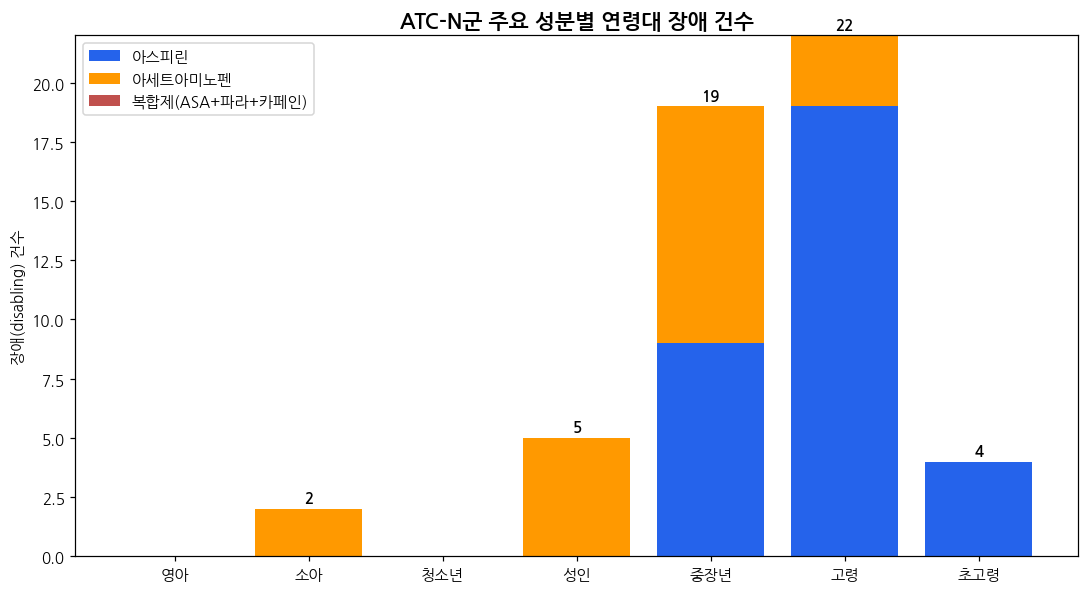

[검정A 성분×장애] 아스피린 1.65% vs 아세트아미노펜 1.97% | chi2=0.24, p = 0.622 (기대빈도 최소 17.8)
[검정B 연령×장애] chi2=0.01, p = 0.909 (기대빈도 최소 25.1)


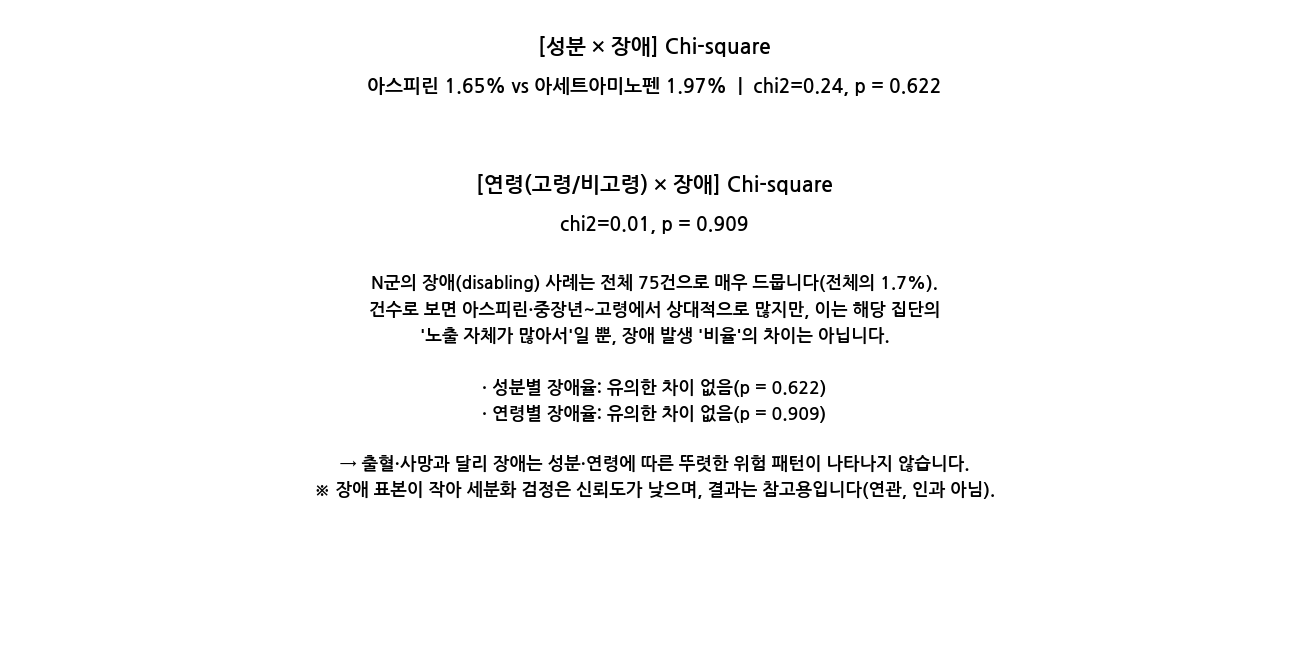

 N군 성분별·연령대 장애 검정 요약
장애 총 75건 | 성분×장애 p = 0.622 | 연령×장애 p = 0.909
→ 출혈·사망과 달리 장애는 유의한 성분·연령 패턴 없음


In [34]:
"""## **N군 주요 성분별 연령대 장애 건수**"""

df['is_N'] = (df['WHO_ATC'] == 'N')
N = df[df['is_N']].copy()
N['disab'] = (N['is_disabling'] == True)
def fmt_p(p): return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


# ---------------------------------------------------------------------
# Self-Refine 1: 성분 정규화 + 표본 진단
# ---------------------------------------------------------------------
# CoT: 먼저 장애 사례가 몇 건인지 본다. 너무 적으면 세분화 검정이 불가하므로,
#   '검정을 어떻게 할지'를 데이터 규모에 맞춰 결정한다(무리한 세분화 지양).
def norm_ing(x):
    x = x.upper()
    x = re.sub(r'\d+\.?\d*\s*(MG|MCG|ML|G|%|IU)', '', x)
    x = re.sub(r'\b(CARDIO|TABLET|TABLETS|EXTENDED|RELEASE|CAPSULE|CAPSULES|ORAL|'
               r'SOLUTION|EC|BUFFERED|ENTERIC|COATED|LOW|DOSE)\b', '', x)
    x = re.sub(r'[^A-Z ]', '', x)
    return re.sub(r'\s+', ' ', x).strip()
SYN = {'ACETYLSALICYLIC ACID':'ASPIRIN', 'PARACETAMOL':'ACETAMINOPHEN'}
def first_ing(s):
    if pd.isna(s): return None
    p = [SYN.get(norm_ing(x), norm_ing(x)) for x in str(s).split(';')
         if norm_ing(x) and 'UNKNOWN' not in norm_ing(x)]
    return p[0] if p else None
N['ing'] = N['suspect_drug'].map(first_ing)

total_disab = int(N['disab'].sum())
print(f"[진단] N군 전체 장애(is_disabling) 건수 = {total_disab}건 / {len(N):,}건 "
      f"({N['disab'].mean()*100:.2f}%)")


# ---------------------------------------------------------------------
# 그래프: 주요 성분(TOP3) × 연령대별 장애 건수 (누적 막대)
# ---------------------------------------------------------------------
# CoT: 요청대로 '건수'를 보여준다. 표본이 작으니 성분 TOP3만, 연령대는 원본 구간.
top3 = N['ing'].value_counts().head(3).index.tolist()
ing_label = {'ASPIRIN':'아스피린','ACETAMINOPHEN':'아세트아미노펜',
             'ACETAMINOPHENASPIRINCAFFEINE':'복합제(ASA+파라+카페인)'}
def lab(i): return ing_label.get(i, i.title()[:14])

age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_kr = {'Infant(0-2)':'영아','Child(3-12)':'소아','Teen(13-18)':'청소년',
          'Adult(19-40)':'성인','Middle-Aged(41-65)':'중장년',
          'Senior(66-80)':'고령','Elderly(81+)':'초고령'}

dd = N[N['disab'] & (N['age_group'] != 'Unknown') & (N['ing'].isin(top3))]
piv = pd.crosstab(dd['age_group'], dd['ing']).reindex(index=age_order, columns=top3).fillna(0).astype(int)

plt.figure(figsize=(10, 5.5))
bottom = np.zeros(len(age_order))
colors = ['#2563eb', '#ff9900', '#c0504d']
for j, ing in enumerate(top3):
    vals = piv[ing].values
    plt.bar([age_kr[a] for a in age_order], vals, bottom=bottom, label=lab(ing), color=colors[j])
    bottom += vals
for i, a in enumerate(age_order):
    tot = piv.loc[a].sum()
    if tot > 0:
        plt.text(i, bottom[i]+0.15, f'{int(tot)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('ATC-N군 주요 성분별 연령대 장애 건수', fontweight='bold', fontsize=14)
plt.ylabel('장애(disabling) 건수'); plt.legend(); plt.tight_layout(); plt.show()


# ---------------------------------------------------------------------
# Self-Refine 2: 검정 (범주 통합 후, 조건 충족 검정만)
# ---------------------------------------------------------------------
# CoT: 3원(성분×연령×장애) 교차는 셀당 기대빈도가 5 미만이라 카이제곱 부적합.
#   → 두 개의 2x2로 분해: (A) 성분(아스피린 vs 아세트아미노펜) × 장애여부,
#     (B) 연령(고령66+ vs 비고령) × 장애여부. 각각 기대빈도 확인 후 보고.
base = N[N['ing'].isin(['ASPIRIN','ACETAMINOPHEN']) & (N['age_group'] != 'Unknown')].copy()
base['disab_i'] = base['disab'].astype(int)

ctA = pd.crosstab(base['ing'], base['disab_i'])
chi2A, pA, dofA, expA = stats.chi2_contingency(ctA)
disab_asp = base.loc[base['ing']=='ASPIRIN', 'disab'].mean()*100
disab_ace = base.loc[base['ing']=='ACETAMINOPHEN', 'disab'].mean()*100

base['aged'] = np.where(base['age_group'].isin(['Senior(66-80)','Elderly(81+)']), '고령(66+)', '비고령')
ctB = pd.crosstab(base['aged'], base['disab_i'])
chi2B, pB, dofB, expB = stats.chi2_contingency(ctB)

print(f"[검정A 성분×장애] 아스피린 {disab_asp:.2f}% vs 아세트아미노펜 {disab_ace:.2f}% | "
      f"chi2={chi2A:.2f}, {fmt_p(pA)} (기대빈도 최소 {expA.min():.1f})")
print(f"[검정B 연령×장애] chi2={chi2B:.2f}, {fmt_p(pB)} (기대빈도 최소 {expB.min():.1f})")


# ---------------------------------------------------------------------
# 통계검정 인사이트 카드
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6)); ax.axis('off')
def block(y, title, lines):
    ax.text(0.5, y, title, ha='center', va='top', fontsize=14,
            fontweight='bold', transform=ax.transAxes)
    for i, ln in enumerate(lines):
        ax.text(0.5, y-0.065-i*0.055, ln, ha='center', va='top',
                fontsize=12.5, fontweight='bold', transform=ax.transAxes)

block(0.96, "[성분 × 장애] Chi-square", [
    f"아스피린 {disab_asp:.2f}% vs 아세트아미노펜 {disab_ace:.2f}%  |  chi2={chi2A:.2f}, {fmt_p(pA)}"])
block(0.74, "[연령(고령/비고령) × 장애] Chi-square", [
    f"chi2={chi2B:.2f}, {fmt_p(pB)}"])

verdict_a = "유의한 차이 없음" if pA >= 0.05 else "유의한 차이 있음"
verdict_b = "유의한 차이 없음" if pB >= 0.05 else "유의한 차이 있음"
interp = (
    f"N군의 장애(disabling) 사례는 전체 {total_disab}건으로 매우 드뭅니다(전체의 {N['disab'].mean()*100:.1f}%).\n"
    "건수로 보면 아스피린·중장년~고령에서 상대적으로 많지만, 이는 해당 집단의\n"
    "'노출 자체가 많아서'일 뿐, 장애 발생 '비율'의 차이는 아닙니다.\n\n"
    f"· 성분별 장애율: {verdict_a}({fmt_p(pA)})\n"
    f"· 연령별 장애율: {verdict_b}({fmt_p(pB)})\n\n"
    "→ 출혈·사망과 달리 장애는 성분·연령에 따른 뚜렷한 위험 패턴이 나타나지 않습니다.\n"
    "※ 장애 표본이 작아 세분화 검정은 신뢰도가 낮으며, 결과는 참고용입니다(연관, 인과 아님)."
)
ax.text(0.5, 0.58, interp, ha='center', va='top', fontsize=11.5,
        fontweight='bold', linespacing=1.6, transform=ax.transAxes)
plt.tight_layout(); plt.show()

print("="*58)
print(" N군 성분별·연령대 장애 검정 요약")
print("="*58)
print(f"장애 총 {total_disab}건 | 성분×장애 {fmt_p(pA)} | 연령×장애 {fmt_p(pB)}")
print(f"→ 출혈·사망과 달리 장애는 유의한 성분·연령 패턴 없음")
print("="*58)